# LOBSTER Limit Order Book EDA — AAPL, 2012-06-21 (10 levels)

## What is a Limit Order Book (LOB)?

A limit order book is the ledger an exchange keeps of all resting (unfilled) buy and sell
orders for one stock, sorted by price:

- **Bids** (buy orders) sorted from highest to lowest price — the highest bid is the
  **best bid**, the price a buyer is currently willing to pay.
- **Asks / offers** (sell orders) sorted from lowest to highest price — the lowest ask is
  the **best ask**, the price a seller is currently willing to accept.
- The gap between best bid and best ask is the **spread**; their average is the
  **mid-price**, the standard reference price for the stock at that instant.

Every new order, cancellation, or trade changes this book. LOBSTER reconstructs the full
book from raw NASDAQ TotalView-ITCH messages, giving us, for every single event, both
**what happened** (the message) and **the resulting state of the book** (the snapshot).

## The dataset

This sample covers **AAPL on 2012-06-21**, the **full regular trading session**
(09:30:00–16:00:00 ET, timestamps in seconds after midnight), reconstructed to
**10 price levels** on each side. Two files, row-aligned 1:1 (row *i* of the orderbook
file is the book state immediately *after* row *i* of the message file is applied):

**Message file** — one row per event:

| col | name | meaning |
|---|---|---|
| 1 | `time` | seconds after midnight, nanosecond precision |
| 2 | `event_type` | 1=New limit order, 2=Partial cancel, 3=Full delete, 4=Visible execution, 5=Hidden execution, 7=Trading halt |
| 3 | `order_id` | unique resting-order identifier |
| 4 | `size` | number of shares |
| 5 | `price` | in **fixed point**, price × 10,000 |
| 6 | `direction` | -1 = sell-side order / sell-initiated trade, 1 = buy-side order / buy-initiated trade |

**Orderbook file** — one row per event, book state after that event:

`ask_price_1, ask_size_1, bid_price_1, bid_size_1, ask_price_2, ask_size_2, ...` up to
level 10. Prices are fixed-point (× 10,000) exactly like the message file.

> Note: execution direction is recorded from the perspective of the **resting (limit)
> order being hit**, not the aggressor. `direction = -1` on an execution means a sell
> limit order was hit, i.e. the trade was **buyer-initiated**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

DATA_DIR = "LOBSTER_SampleFile_AAPL_2012-06-21_10"
MSG_FILE = f"{DATA_DIR}/AAPL_2012-06-21_34200000_57600000_message_10.csv"
OB_FILE = f"{DATA_DIR}/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv"
N_LEVELS = 10
TICK = 0.01  # NASDAQ minimum tick size for stocks > $1

EVENT_TYPE_LABELS = {
    1: "New limit order",
    2: "Partial cancel",
    3: "Full delete",
    4: "Execution (visible)",
    5: "Execution (hidden)",
    7: "Trading halt",
}


## 1. Load the data

Neither file ships column headers, so we supply them explicitly and immediately rescale
prices from LOBSTER's fixed-point integers (× 10,000) to dollars. We also convert `time`
(seconds after midnight) into a proper time-of-day for readable axes.

In [2]:
msg_cols = ["time", "event_type", "order_id", "size", "price", "direction"]

ob_cols = []
for lvl in range(1, N_LEVELS + 1):
    ob_cols += [f"ask_price_{lvl}", f"ask_size_{lvl}", f"bid_price_{lvl}", f"bid_size_{lvl}"]

df_msg = pd.read_csv(MSG_FILE, names=msg_cols)
df_ob = pd.read_csv(OB_FILE, names=ob_cols)

assert len(df_msg) == len(df_ob), "message and orderbook files must be row-aligned"

# Rescale fixed-point prices (x10,000) to dollars
df_msg["price"] = df_msg["price"] / 10_000
price_cols = [c for c in df_ob.columns if "price" in c]
df_ob[price_cols] = df_ob[price_cols] / 10_000

# Human-readable time-of-day, still keeping the original float seconds for arithmetic
df_msg["time_sec"] = df_msg["time"]
df_msg["time"] = pd.to_datetime(df_msg["time_sec"], unit="s", origin=pd.Timestamp("2012-06-21"))
df_msg["event_label"] = df_msg["event_type"].map(EVENT_TYPE_LABELS)

# One combined frame: each row = an event + the resulting book state
df = pd.concat([df_msg, df_ob], axis=1)

print(f"{len(df):,} events from {df_msg['time'].min().time()} to {df_msg['time'].max().time()}")
df.head()

400,391 events from 09:30:00.004241 to 15:59:59.913117


,time,event_type,order_id,size,price,direction,time_sec,event_label,ask_price_1,ask_size_1,bid_price_1,bid_size_1,ask_price_2,ask_size_2,bid_price_2,bid_size_2,ask_price_3,ask_size_3,bid_price_3,bid_size_3,ask_price_4,ask_size_4,bid_price_4,bid_size_4,ask_price_5,ask_size_5,bid_price_5,bid_size_5,ask_price_6,ask_size_6,bid_price_6,bid_size_6,ask_price_7,ask_size_7,bid_price_7,bid_size_7,ask_price_8,ask_size_8,bid_price_8,bid_size_8,ask_price_9,ask_size_9,bid_price_9,bid_size_9,ask_price_10,ask_size_10,bid_price_10,bid_size_10
0,2012-06-21 09:30:00.004241228,1,16113575,18,585.33,1,34200.004241,New limit order,585.94,200,585.33,18,585.98,200,585.30,150,586.10,200,585.10,5,586.89,300,585.01,89,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300,587.39,100,584.53,300,587.65,1160,584.38,200,587.90,500,584.27,300
1,2012-06-21 09:30:00.004260540,1,16113584,18,585.32,1,34200.004261,New limit order,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,585.30,150,586.89,300,585.10,5,586.95,50,585.01,89,587.00,100,584.97,5,587.10,10,584.93,300,587.39,100,584.65,300,587.65,1160,584.53,300,587.90,500,584.38,200
2,2012-06-21 09:30:00.004447460,1,16113594,18,585.31,1,34200.004447,New limit order,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,585.31,18,586.89,300,585.30,150,586.95,50,585.10,5,587.00,100,585.01,89,587.10,10,584.97,5,587.39,100,584.93,300,587.65,1160,584.65,300,587.90,500,584.53,300
3,2012-06-21 09:30:00.025551796,1,16120456,18,585.91,-1,34200.025552,New limit order,585.91,18,585.33,18,585.94,200,585.32,18,585.98,200,585.31,18,586.10,200,585.30,150,586.89,300,585.10,5,586.95,50,585.01,89,587.00,100,584.97,5,587.10,10,584.93,300,587.39,100,584.65,300,587.65,1160,584.53,300
4,2012-06-21 09:30:00.025579453,1,16120480,18,585.92,-1,34200.025580,New limit order,585.91,18,585.33,18,585.92,18,585.32,18,585.94,200,585.31,18,585.98,200,585.30,150,586.10,200,585.10,5,586.89,300,585.01,89,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300,587.39,100,584.53,300


## 2. Sanity checks

Confirm shapes, dtypes, and that there's no missing data before trusting any downstream
statistic.

In [3]:
print("Shapes:", df_msg.shape, df_ob.shape)
print("\nMissing values (msg):", df_msg.isna().sum().sum(), " | (orderbook):", df_ob.isna().sum().sum())
print("\nUnique order IDs:", df_msg["order_id"].nunique(), "/ events:", len(df_msg))
print("Trading halts (type 7):", (df_msg["event_type"] == 7).sum())

# The book should always be internally consistent: best ask > best bid at every event
crossed = (df_ob["ask_price_1"] <= df_ob["bid_price_1"]).sum()
print("Crossed-book events (ask_1 <= bid_1):", crossed)

df_msg[["time_sec", "size", "price"]].describe()

Shapes: (400391, 8) (400391, 40)

Missing values (msg): 0  | (orderbook): 0

Unique order IDs: 198668 / events: 400391
Trading halts (type 7): 0
Crossed-book events (ask_1 <= bid_1): 0


,time_sec,size,price
count,400391.000000,400391.000000,400391.000000
mean,46281.368129,88.740891,583.170209
std,7490.018003,94.838261,2.837093
min,34200.004241,1.000000,577.350000
25%,39551.398939,24.000000,581.240000
50%,45969.414798,100.000000,583.290000
75%,53517.590507,100.000000,585.660000
max,57599.913118,15000.000000,588.320000


## 3. Event type & order-flow composition

What kind of activity fills the book? Most events are order placements and cancellations
— actual trades (executions) are a minority. This ratio is a basic signature of
electronic markets: liquidity providers post and pull orders far more often than trades
actually happen.

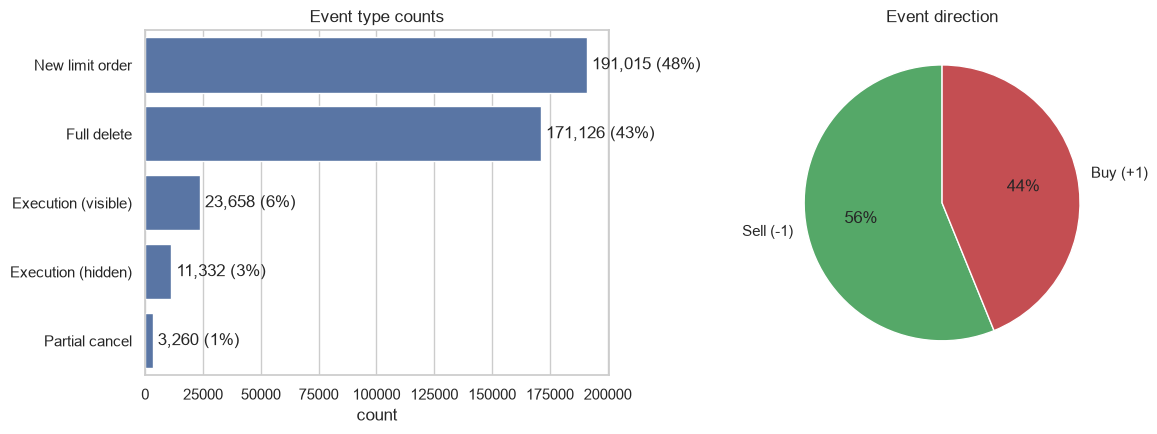

Executions are 8.7% of all events (23,658 visible + 11,332 hidden)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

event_counts = df_msg["event_label"].value_counts()
sns.barplot(x=event_counts.values, y=event_counts.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Event type counts")
axes[0].set_xlabel("count")
axes[0].set_ylabel("")
for i, v in enumerate(event_counts.values):
    axes[0].text(v, i, f" {v:,} ({v/len(df_msg):.0%})", va="center")

direction_counts = df_msg["direction"].map({1: "Buy (+1)", -1: "Sell (-1)"}).value_counts()
axes[1].pie(direction_counts.values, labels=direction_counts.index, autopct="%1.0f%%",
            colors=["#55A868", "#C44E52"], startangle=90)
axes[1].set_title("Event direction")

plt.tight_layout()
plt.show()

trades = df_msg[df_msg["event_type"].isin([4, 5])]
print(f"Executions are {len(trades)/len(df_msg):.1%} of all events "
      f"({(df_msg['event_type']==4).sum():,} visible + {(df_msg['event_type']==5).sum():,} hidden)")

## 4. Intraday activity pattern

Bucket events into 1-minute bins across the session. Equity markets famously trade in a
**U-shape**: heavy activity right at the open and into the close, quieter through the
midday lull.

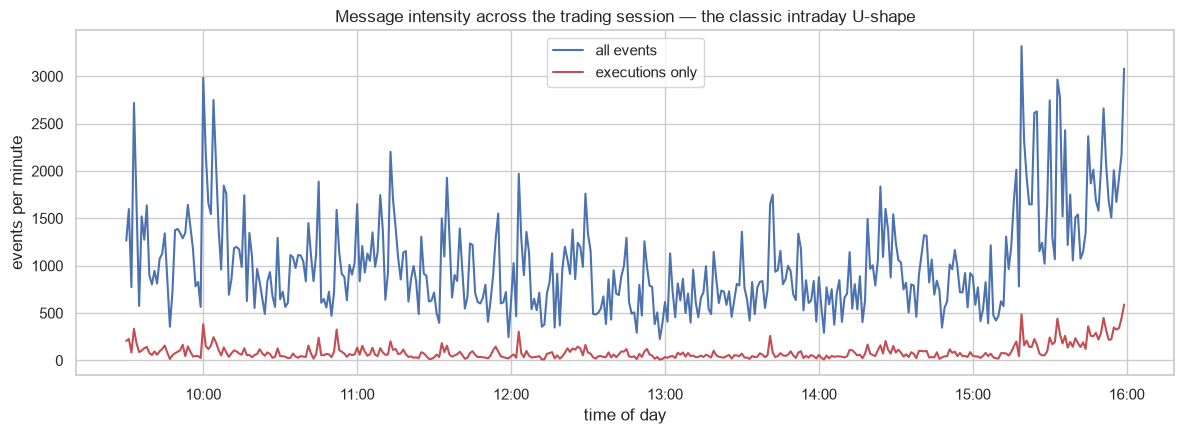

In [5]:
events_per_min = df_msg.set_index("time").resample("1min").size()
trades_per_min = trades.set_index("time").resample("1min").size()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(events_per_min.index, events_per_min.values, label="all events", color="#4C72B0")
ax.plot(trades_per_min.index, trades_per_min.values, label="executions only", color="#C44E52")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("time of day")
ax.set_ylabel("events per minute")
ax.set_title("Message intensity across the trading session — the classic intraday U-shape")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Event inter-arrival times

The time gap between consecutive events. In real markets this is **not** exponential /
memoryless — activity clusters in bursts (algorithms firing in quick sequences), so we
expect a heavy right tail even on a log scale, and a spike near zero from same-timestamp
or sub-millisecond bursts.

count    400390.000000
mean         58.442790
std         208.833216
min           0.000000
25%           0.073261
50%           0.638858
75%           9.319839
max        8155.205382
Name: time_sec, dtype: float64



Median gap: 0.639 ms | 99th pct: 997.8 ms


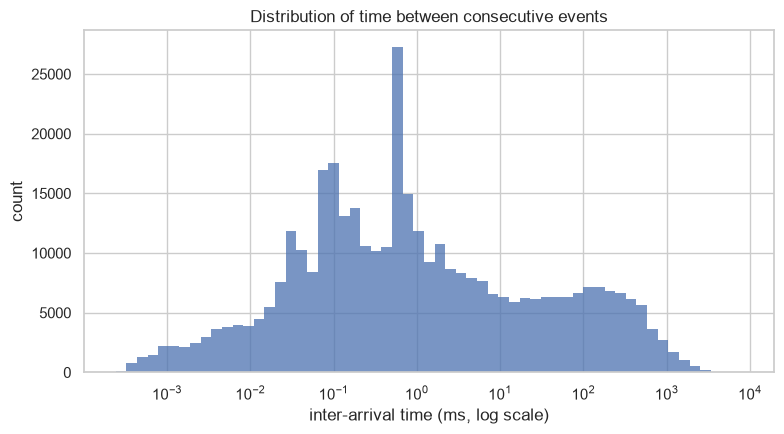

In [6]:
inter_arrival = df_msg["time_sec"].diff().dropna()
inter_arrival_ms = inter_arrival * 1000

print(inter_arrival_ms.describe())
print(f"\nMedian gap: {inter_arrival_ms.median():.3f} ms | 99th pct: {inter_arrival_ms.quantile(0.99):.1f} ms")

fig, ax = plt.subplots(figsize=(8, 4.5))
positive = inter_arrival_ms[inter_arrival_ms > 0]
sns.histplot(positive, bins=np.logspace(np.log10(positive.min()), np.log10(positive.max()), 60),
             ax=ax, color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("inter-arrival time (ms, log scale)")
ax.set_ylabel("count")
ax.set_title("Distribution of time between consecutive events")
plt.tight_layout()
plt.show()

## 6. Mid-price and spread

Two of the most fundamental derived series in market microstructure:

- **mid-price** = (best bid + best ask) / 2 — the reference "fair value" proxy
- **spread** = best ask − best bid — the cost of demanding immediacy; compensation
  liquidity providers earn for standing ready to trade

We also express spread **in ticks** (spread ÷ $0.01), since on NASDAQ the spread is
constrained to be a whole number of ticks.

count    400391.000000
mean        583.152849
std           2.834982
min         577.480000
25%         581.245000
50%         583.235000
75%         585.660000
max         588.185000
Name: mid_price, dtype: float64

count    400391.000000
mean         15.348894
std           7.415759
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          92.000000
Name: spread_ticks, dtype: float64


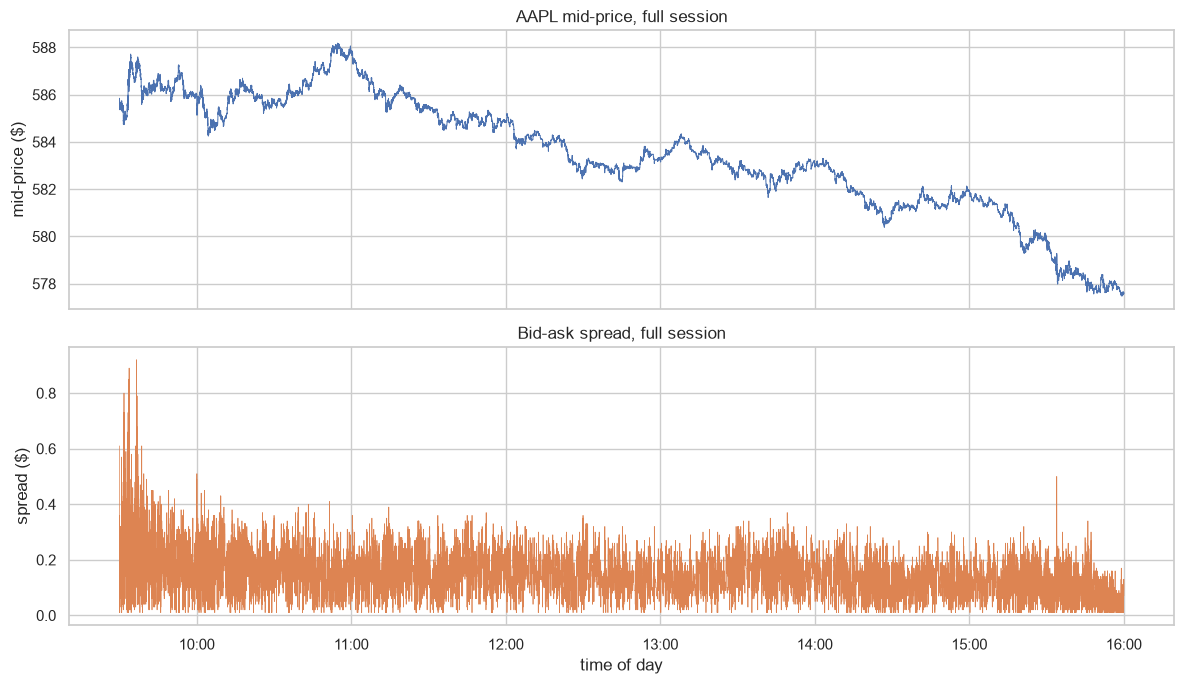

In [7]:
df["mid_price"] = (df["ask_price_1"] + df["bid_price_1"]) / 2
df["spread"] = df["ask_price_1"] - df["bid_price_1"]
df["spread_ticks"] = (df["spread"] / TICK).round().astype(int)

print(df["mid_price"].describe())
print()
print(df["spread_ticks"].describe())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df["time"], df["mid_price"], color="#4C72B0", linewidth=0.7)
axes[0].set_ylabel("mid-price ($)")
axes[0].set_title("AAPL mid-price, full session")

axes[1].plot(df["time"], df["spread"], color="#DD8452", linewidth=0.5)
axes[1].set_ylabel("spread ($)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_title("Bid-ask spread, full session")

plt.tight_layout()
plt.show()

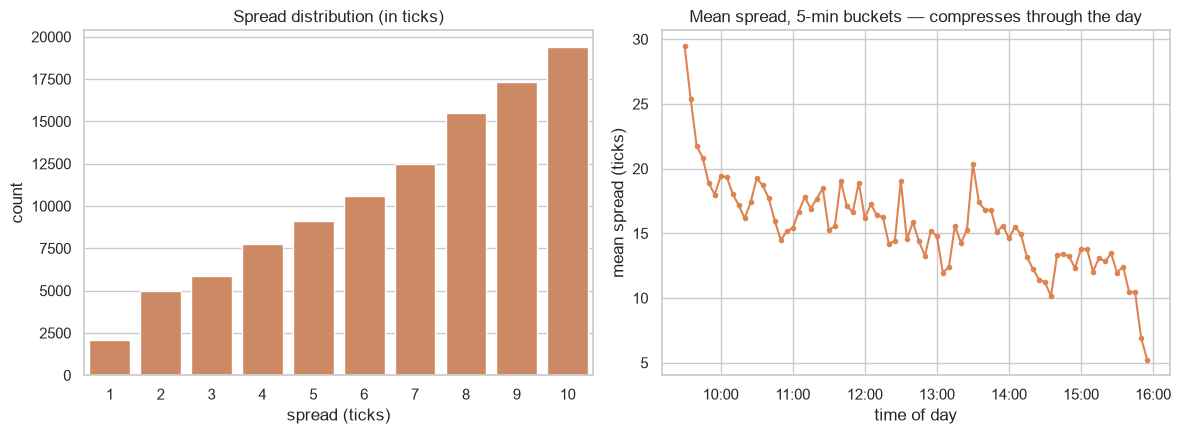

1-tick (minimum) spread holds 0.5% of the time


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

spread_counts = df["spread_ticks"].value_counts().sort_index().head(10)
sns.barplot(x=spread_counts.index, y=spread_counts.values, ax=axes[0], color="#DD8452")
axes[0].set_xlabel("spread (ticks)")
axes[0].set_ylabel("count")
axes[0].set_title("Spread distribution (in ticks)")

spread_by_min = df.set_index("time")["spread_ticks"].resample("5min").mean()
axes[1].plot(spread_by_min.index, spread_by_min.values, color="#DD8452", marker="o", markersize=3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_ylabel("mean spread (ticks)")
axes[1].set_title("Mean spread, 5-min buckets — compresses through the day")

plt.tight_layout()
plt.show()

print(f"1-tick (minimum) spread holds {(df['spread_ticks']==1).mean():.1%} of the time")

## 7. Order book shape

Average resting size at each of the 10 levels, and a snapshot of the actual book at one
instant. Size typically grows away from the best price — the top of book is thin (it
absorbs the most competition) while deeper levels accumulate more resting size.

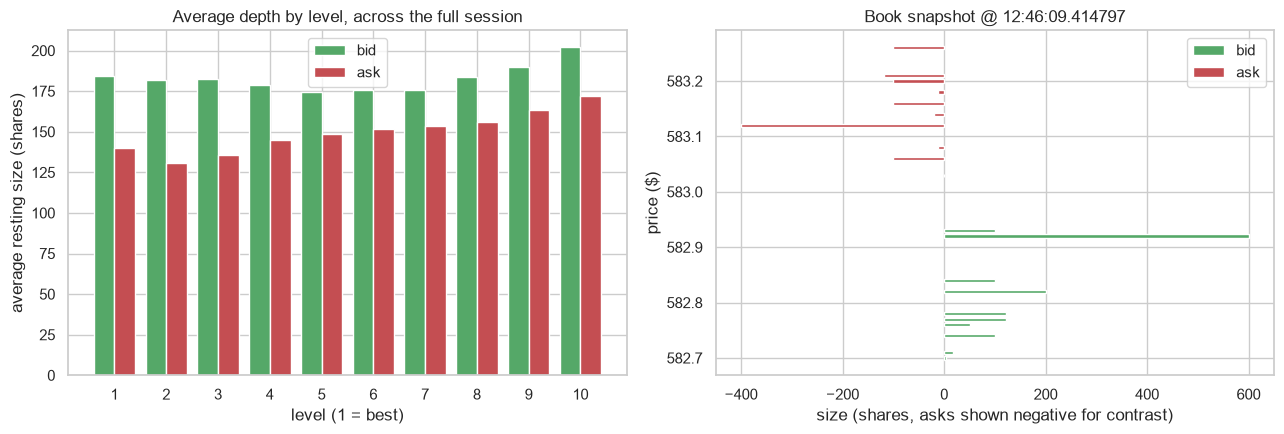

In [9]:
avg_bid_size = [df_ob[f"bid_size_{lvl}"].mean() for lvl in range(1, N_LEVELS + 1)]
avg_ask_size = [df_ob[f"ask_size_{lvl}"].mean() for lvl in range(1, N_LEVELS + 1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

levels = np.arange(1, N_LEVELS + 1)
width = 0.4
axes[0].bar(levels - width/2, avg_bid_size, width, label="bid", color="#55A868")
axes[0].bar(levels + width/2, avg_ask_size, width, label="ask", color="#C44E52")
axes[0].set_xlabel("level (1 = best)")
axes[0].set_ylabel("average resting size (shares)")
axes[0].set_title("Average depth by level, across the full session")
axes[0].set_xticks(levels)
axes[0].legend()

# Snapshot: the actual book at a single instant (midday)
snap_idx = df.index[len(df) // 2]
snap = df.loc[snap_idx]
bid_prices = [snap[f"bid_price_{lvl}"] for lvl in range(1, N_LEVELS + 1)]
bid_sizes = [snap[f"bid_size_{lvl}"] for lvl in range(1, N_LEVELS + 1)]
ask_prices = [snap[f"ask_price_{lvl}"] for lvl in range(1, N_LEVELS + 1)]
ask_sizes = [snap[f"ask_size_{lvl}"] for lvl in range(1, N_LEVELS + 1)]

axes[1].barh(bid_prices, bid_sizes, height=0.006, color="#55A868", label="bid")
axes[1].barh(ask_prices, [-s for s in ask_sizes], height=0.006, color="#C44E52", label="ask")
axes[1].set_xlabel("size (shares, asks shown negative for contrast)")
axes[1].set_ylabel("price ($)")
axes[1].set_title(f"Book snapshot @ {snap['time'].time()}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Order book imbalance vs. future price moves

**Order book imbalance (OBI)** at the top of book:

$$\text{OBI} = \frac{\text{bid\_size}_1 - \text{ask\_size}_1}{\text{bid\_size}_1 + \text{ask\_size}_1} \in [-1, 1]$$

Positive OBI means more resting buy interest than sell interest at the best prices — a
textbook short-horizon signal that price should tick **up** next (more buyers waiting =
sellers get lifted first), and vice versa. We check this by binning OBI at each event and
looking at the mid-price change over the next 50 events.

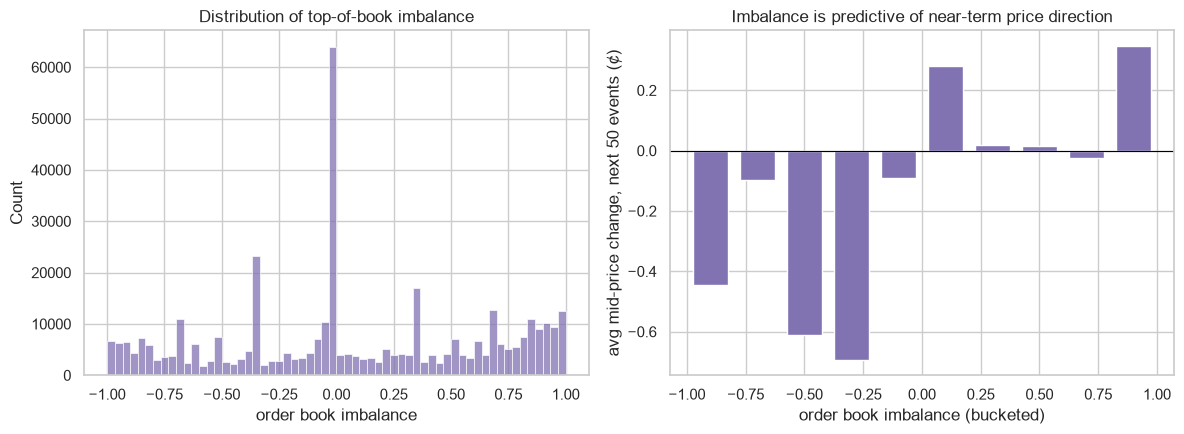

Correlation(OBI, future mid-price change): 0.0442


In [10]:
df["obi"] = (df["bid_size_1"] - df["ask_size_1"]) / (df["bid_size_1"] + df["ask_size_1"])

HORIZON = 50  # events ahead
df["future_mid_change"] = df["mid_price"].shift(-HORIZON) - df["mid_price"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df["obi"], bins=60, ax=axes[0], color="#8172B2")
axes[0].set_xlabel("order book imbalance")
axes[0].set_title("Distribution of top-of-book imbalance")

valid = df.dropna(subset=["future_mid_change"]).copy()
valid["obi_bin"] = pd.cut(valid["obi"], bins=np.linspace(-1, 1, 11))
binned = valid.groupby("obi_bin", observed=True)["future_mid_change"].mean() * 100  # in cents
bin_centers = [interval.mid for interval in binned.index]

axes[1].bar(bin_centers, binned.values, width=0.15, color="#8172B2")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("order book imbalance (bucketed)")
axes[1].set_ylabel(f"avg mid-price change, next {HORIZON} events (¢)")
axes[1].set_title("Imbalance is predictive of near-term price direction")

plt.tight_layout()
plt.show()

print("Correlation(OBI, future mid-price change):", valid["obi"].corr(valid["future_mid_change"]).round(4))

## 9. Trades: size, sign, and volume profile

Filtering to executions only (`event_type` 4 or 5). Recall `direction = -1` on an
execution means a **resting sell** order was hit → the trade was **buyer-initiated**;
`direction = 1` means seller-initiated.

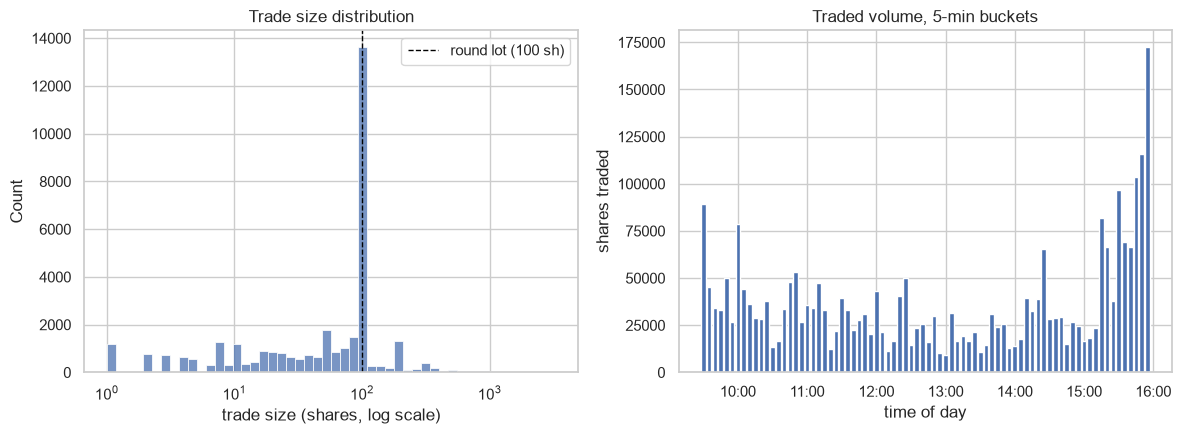

                  count      sum       mean
initiator                                  
buyer-initiated   16729  1314336  78.566322
seller-initiated  18261  1535804  84.102952

% of executed volume that is buyer-initiated: 46.1%


In [11]:
trades = trades.copy()
trades["initiator"] = trades["direction"].map({-1: "buyer-initiated", 1: "seller-initiated"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(trades["size"], bins=50, log_scale=(True, False), ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("trade size (shares, log scale)")
axes[0].set_title("Trade size distribution")
axes[0].axvline(100, color="black", linestyle="--", linewidth=1, label="round lot (100 sh)")
axes[0].legend()

volume_by_min = trades.set_index("time").groupby(pd.Grouper(freq="5min"))["size"].sum()
axes[1].bar(volume_by_min.index, volume_by_min.values, width=0.0028, color="#4C72B0")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_ylabel("shares traded")
axes[1].set_title("Traded volume, 5-min buckets")

plt.tight_layout()
plt.show()

print(trades.groupby("initiator")["size"].agg(["count", "sum", "mean"]))
print(f"\n% of executed volume that is buyer-initiated: "
      f"{trades.loc[trades['initiator']=='buyer-initiated','size'].sum() / trades['size'].sum():.1%}")

## 10. New limit order sizes

Order sizes tend to cluster on **round lots** (multiples of 100 shares) — a well-known
artifact of how both human traders and execution algorithms slice orders.

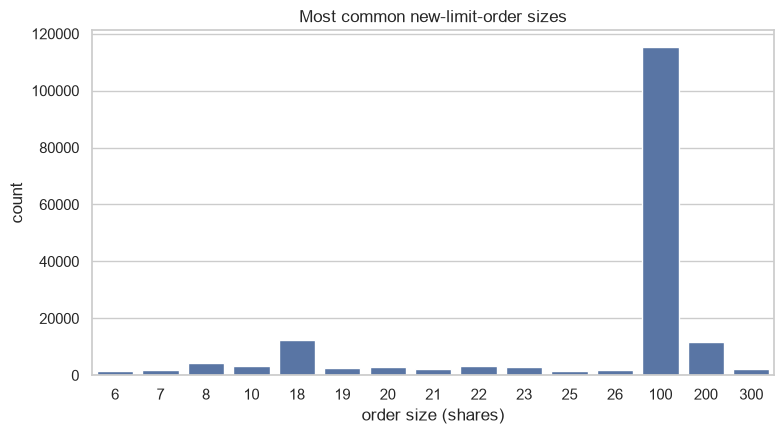

Share of new orders that are an exact multiple of 100 shares: 68.6%


In [12]:
new_orders = df_msg[df_msg["event_type"] == 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
top_sizes = new_orders["size"].value_counts().head(15).sort_index()
sns.barplot(x=top_sizes.index.astype(str), y=top_sizes.values, ax=ax, color="#4C72B0")
ax.set_xlabel("order size (shares)")
ax.set_ylabel("count")
ax.set_title("Most common new-limit-order sizes")
plt.tight_layout()
plt.show()

round_lot_share = (new_orders["size"] % 100 == 0).mean()
print(f"Share of new orders that are an exact multiple of 100 shares: {round_lot_share:.1%}")

## Summary

- ~400k events over one session; **new orders (48%)** and **full deletes (43%)** dominate,
  executions are under 9% — the book churns far more than it trades.
- Message intensity and traded volume both show the classic **intraday U-shape**: busy
  at the open, quiet at midday, busiest of all into the close.
- Event inter-arrival times are **heavy-tailed / bursty**, not memoryless — consistent
  with clustered, algorithmic order flow rather than a simple Poisson process.
- The spread is **not** pinned at the 1-tick minimum here — that only happens 0.5% of
  the time. Instead it **compresses steadily through the day**, from a wide ~26 ticks
  (~$0.26) right after the open down to ~7 ticks by the close, with a session median
  around 15 ticks (~$0.15) on a ~$583 stock.
- Book depth **grows away from the touch** — level 1 is thin, deeper levels hold more
  resting size.
- **Order book imbalance predicts short-horizon price direction**: buy-heavy books tend
  to tick up next, sell-heavy books tick down — the correlation is modest but
  directionally consistent, which is exactly the kind of signal high-frequency market
  making strategies exploit.
- Order sizes cluster heavily on **round lots** (69% of new orders are exact multiples
  of 100 shares); buyer- and seller-initiated trade volume are roughly balanced (46%/54%).

### Natural next steps
- Extend this pipeline to the 1/5/30/50-level files or other tickers (AMZN, GOOG, INTC,
  MSFT, SPY) to compare liquidity profiles across names.
- Build a feature set (OBI at multiple levels, queue position, realized volatility,
  trade-flow imbalance) for a short-horizon price-direction model.
- Model the event stream itself with a **Hawkes process** to capture the self-exciting
  clustering seen in the inter-arrival plot.

# Part 2 — TWAP execution simulation

**TWAP (Time-Weighted Average Price)** execution splits a large "parent" order into
equal-sized "child" slices spaced evenly across a time window, on the theory that
trading steadily over time — rather than all at once — reduces market impact and
avoids betting on *when* during the window the price is best.

We simulate a **10,000-share buy** (≈0.35% of the day's ~2.85M-share volume — small
enough that a no-market-impact assumption is reasonable) split into 20 equal-time
slices across the full session. Each slice is filled as an **aggressive marketable
order that walks the book**: it takes level 1, then level 2, etc., against the
*actual historical order book* at that moment, until the slice is fully filled. This
is a conservative baseline — real execution algorithms often post passively and can
do better — but it gives a clean worst-case cost estimate purely from the book's
displayed liquidity.

Two caveats worth being explicit about:
- **No feedback loop**: our hypothetical fills consume liquidity from the snapshot
  for cost purposes but don't alter the historical book that later events see. This
  is the standard simplification for backtesting execution against historical LOB
  data.
- **Two different benchmarks** answer two different questions:
  - **Implementation Shortfall** (vs. the arrival mid-price at 09:30:00) captures
    *total* cost — spread/impact **plus** whatever the market did over the day.
  - **TWAP benchmark** (the size-weighted average of the mid-price observed at each
    slice) isolates *execution quality* — did we cross the spread and walk the book
    more expensively than the prevailing price at the time, independent of the
    day's overall drift?

The code below is a corrected version of the original draft: share counts are now
integers that sum exactly to the target (the draft used `total_shares / n_trades`,
which only sums exactly when it happens to divide evenly), snapshot lookups are
bounds-checked so a schedule time at or past the last event can't crash with an
`IndexError`, and each trade's contemporaneous mid-price and per-slice slippage are
recorded for the benchmark and plots below.

In [13]:
def simulate_scheduled_execution(df_msg, df_ob, target_times, total_shares, arrival_sec=None, label="Execution"):
    """
    범용 스케줄 기반 매수 실행 엔진.

    target_times의 각 시각마다 total_shares를 균등 분할한 슬라이스 하나를, 그 시점의
    과거 오더북 스냅샷에서 호가창을 잠식(walk the book)하는 시장가로 체결한다고 가정한다.
    naive single-shot(스케줄 1개), TWAP(균등 시간 스케줄), VWAP(거래량 클록 스케줄)은
    모두 이 함수에 서로 다른 target_times를 넘기는 특수 케이스일 뿐이다.

    arrival_sec(모(母)주문이 발생한 진짜 의사결정 시점)은 스케줄의 첫 체결 시각과 별개다.
    TWAP/naive는 둘이 같지만(첫 슬라이스가 곧 09:30:00), VWAP은 첫 거래량-클록 슬라이스가
    한참 뒤에 발생할 수 있으므로 반드시 분리해서 계산해야 Implementation Shortfall이
    스케줄 간에 공정하게 비교된다. 지정하지 않으면 target_times[0]을 그대로 사용한다.

    :param df_msg: LOBSTER 메시지 DataFrame (time_sec 컬럼 포함)
    :param df_ob: LOBSTER 오더북 DataFrame (달러 단위 가격)
    :param target_times: 각 슬라이스를 체결할 목표 시각(초) 리스트/배열
    :param total_shares: 총 매수 목표 수량
    :param arrival_sec: 모주문의 의사결정 시각(초). None이면 target_times[0] 사용
    :param label: 출력용 라벨
    :return: (summary dict, trades DataFrame)
    """
    n_trades = len(target_times)
    n_levels = sum(1 for c in df_ob.columns if c.startswith("ask_price_"))
    time_arr = df_msg["time_sec"].values
    last_idx = len(df_ob) - 1

    # 정수 수량 스케줄: 나머지는 앞쪽 슬라이스에 1주씩 배분해 합계가 정확히 total_shares가 되도록 함
    base_size, remainder = divmod(total_shares, n_trades)
    slice_sizes = [base_size + 1 if i < remainder else base_size for i in range(n_trades)]

    if arrival_sec is None:
        arrival_sec = target_times[0]
    idx_start = min(np.searchsorted(time_arr, arrival_sec), last_idx)
    arrival_price = (df_ob.iloc[idx_start]["ask_price_1"] + df_ob.iloc[idx_start]["bid_price_1"]) / 2.0

    records = []
    total_cost = 0.0

    for i, (t, size) in enumerate(zip(target_times, slice_sizes)):
        if size == 0:
            continue
        idx = min(np.searchsorted(time_arr, t), last_idx)
        ob_state = df_ob.iloc[idx]
        mid_price = (ob_state["ask_price_1"] + ob_state["bid_price_1"]) / 2.0

        shares_remaining = size
        cost = 0.0
        lvl = 1
        while shares_remaining > 0 and lvl <= n_levels:
            ask_price = ob_state[f"ask_price_{lvl}"]
            ask_size = ob_state[f"ask_size_{lvl}"]
            fill = min(shares_remaining, ask_size)
            cost += fill * ask_price
            shares_remaining -= fill
            if shares_remaining > 0:
                lvl += 1

        levels_walked = min(lvl, n_levels)
        if shares_remaining > 0:
            print(f"[{label}] Warning: depth exhausted to level {n_levels} at t={t:.1f}s "
                  f"({shares_remaining} sh short) — filling remainder at level-{n_levels} price")
            cost += shares_remaining * ob_state[f"ask_price_{n_levels}"]
            shares_remaining = 0

        avg_price = cost / size
        total_cost += cost
        records.append({
            "trade_num": i + 1,
            "time_sec": t,
            "shares": size,
            "avg_fill_price": avg_price,
            "contemporaneous_mid": mid_price,
            "slippage_vs_mid_bps": (avg_price - mid_price) / mid_price * 10_000,
            "levels_walked": levels_walked,
        })

    trades_df = pd.DataFrame(records)

    avg_execution_price = total_cost / total_shares
    is_dollars = avg_execution_price - arrival_price
    is_bps = is_dollars / arrival_price * 10_000

    # size-가중 평균 contemporaneous mid = 이 스케줄 자체의 "벤치마크 가격"
    benchmark_price = np.average(trades_df["contemporaneous_mid"], weights=trades_df["shares"])
    vs_benchmark_dollars = avg_execution_price - benchmark_price
    vs_benchmark_bps = vs_benchmark_dollars / benchmark_price * 10_000

    summary = {
        "label": label,
        "total_shares": total_shares,
        "n_trades": n_trades,
        "arrival_price": arrival_price,
        "benchmark_price": benchmark_price,
        "avg_execution_price": avg_execution_price,
        "IS_dollars": is_dollars,
        "IS_bps": is_bps,
        "vs_benchmark_dollars": vs_benchmark_dollars,
        "vs_benchmark_bps": vs_benchmark_bps,
        "avg_levels_walked": trades_df["levels_walked"].mean(),
    }

    print(f"--- {label}: Execution Summary ---")
    print(f"Total shares          : {total_shares:,} in {n_trades} slice(s)")
    print(f"Arrival mid-price     : ${arrival_price:.4f}")
    print(f"Benchmark price       : ${benchmark_price:.4f}  (size-wtd avg mid at each slice)")
    print(f"Avg execution price   : ${avg_execution_price:.4f}")
    print(f"Avg levels walked     : {summary['avg_levels_walked']:.1f} / {n_levels}")
    print(f"Implementation Shortfall vs arrival : {is_dollars:+.4f} ({is_bps:+.2f} bps)")
    print(f"Slippage vs benchmark                : {vs_benchmark_dollars:+.4f} ({vs_benchmark_bps:+.2f} bps)\n")

    return summary, trades_df


def simulate_twap_buy(df_msg, df_ob, total_shares=10_000, n_trades=20, start_sec=34_200, end_sec=57_600):
    """TWAP: n_trades개 슬라이스를 실행 구간에 걸쳐 균등한 시간 간격으로 배치."""
    target_times = np.linspace(start_sec, end_sec - 1, n_trades)
    return simulate_scheduled_execution(df_msg, df_ob, target_times, total_shares,
                                         arrival_sec=start_sec, label="TWAP (time-clock)")


summary, trades_df = simulate_twap_buy(df_msg, df_ob, total_shares=10_000, n_trades=20)
trades_df

--- TWAP (time-clock): Execution Summary ---
Total shares          : 10,000 in 20 slice(s)
Arrival mid-price     : $585.6350
Benchmark price       : $583.4098  (size-wtd avg mid at each slice)
Avg execution price   : $583.5521
Avg levels walked     : 4.9 / 10
Implementation Shortfall vs arrival : -2.0829 (-35.57 bps)
Slippage vs benchmark                : +0.1423 (+2.44 bps)



,trade_num,time_sec,shares,avg_fill_price,contemporaneous_mid,slippage_vs_mid_bps,levels_walked
0,1,34200.000000,500,585.98800,585.635,6.027645,3
1,2,35431.526316,500,586.14518,586.005,2.392130,4
2,3,36663.052632,500,585.11950,585.000,2.042735,4
3,4,37894.578947,500,585.94848,585.790,2.705406,6
4,5,39126.105263,500,587.57594,587.515,1.037250,2
5,6,40357.631579,500,586.24860,586.090,2.706069,5
6,7,41589.157895,500,585.43208,585.345,1.487670,4
7,8,42820.684211,500,585.33684,585.185,2.594735,3
8,9,44052.210526,500,584.20612,584.085,2.073671,9
9,10,45283.736842,500,583.28970,583.045,4.196932,9


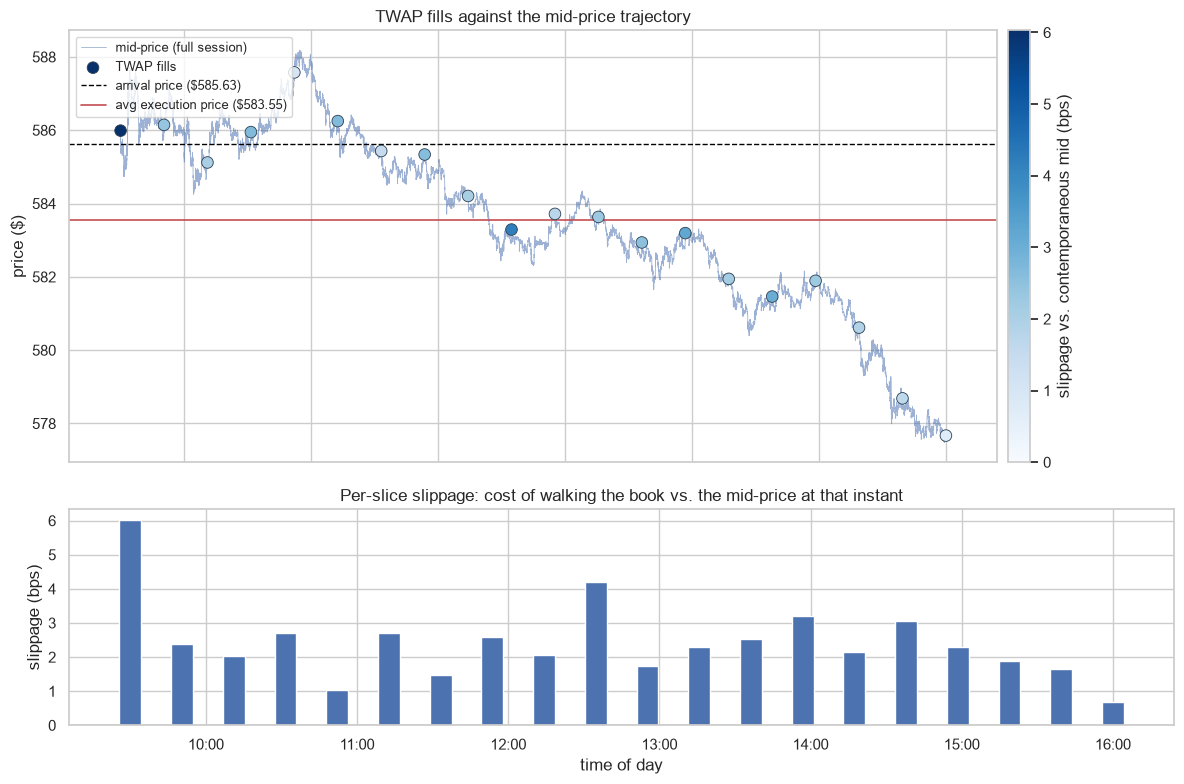

In [14]:
trades_df["time"] = pd.to_datetime(trades_df["time_sec"], unit="s", origin=pd.Timestamp("2012-06-21"))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[2, 1])

axes[0].plot(df["time"], df["mid_price"], color="#4C72B0", linewidth=0.6, alpha=0.55, label="mid-price (full session)")

# every fill crosses the spread, so slippage is strictly positive here — a magnitude,
# not a polarity — so a single-hue sequential scale is used rather than a diverging one
sc = axes[0].scatter(trades_df["time"], trades_df["avg_fill_price"],
                      c=trades_df["slippage_vs_mid_bps"], cmap="Blues",
                      vmin=0, vmax=trades_df["slippage_vs_mid_bps"].max(),
                      s=70, edgecolor="#2c3e50", linewidth=0.6, zorder=5, label="TWAP fills")

axes[0].axhline(summary["arrival_price"], color="black", linestyle="--", linewidth=1,
                label=f"arrival price (${summary['arrival_price']:.2f})")
axes[0].axhline(summary["avg_execution_price"], color="#C44E52", linestyle="-", linewidth=1.2,
                label=f"avg execution price (${summary['avg_execution_price']:.2f})")
axes[0].set_ylabel("price ($)")
axes[0].set_title("TWAP fills against the mid-price trajectory")
axes[0].legend(loc="upper left", fontsize=9)
cbar = plt.colorbar(sc, ax=axes[0], pad=0.01)
cbar.set_label("slippage vs. contemporaneous mid (bps)")

axes[1].bar(trades_df["time"], trades_df["slippage_vs_mid_bps"], width=0.006, color="#4C72B0")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_ylabel("slippage (bps)")
axes[1].set_title("Per-slice slippage: cost of walking the book vs. the mid-price at that instant")

plt.tight_layout()
plt.show()

## Results

- **Implementation Shortfall: −35.6 bps** ($585.64 arrival → $583.55 average execution).
  This is *favorable* for the buyer, but for the wrong reason from an execution
  standpoint: AAPL simply drifted down about 1.3% over the session, and spacing the
  order out let most of it fill at the lower afternoon prices. This number is really
  measuring the day's price drift, not skill.
- **Slippage vs. the TWAP benchmark: +2.4 bps** ($583.41 benchmark → $583.55 executed).
  This is the honest measure of *execution quality* — the small, consistent cost of
  crossing the spread and walking the book on every single slice. Every one of the
  20 slices has positive slippage (range: 0.7–6.0 bps, see the chart), because a
  marketable buy against ~500 shares of resting ask depth almost always has to eat
  into level 2 or deeper (avg. **4.9 of 10 levels** walked per slice) — consistent
  with the thin top-of-book size found in Part 1, section 7.
- The two benchmarks decompose total cost cleanly: **−35.6 bps total ≈ −38.0 bps of
  favorable market drift + 2.4 bps of execution cost.** A pure passive strategy
  (resting limit orders instead of walking the book) would likely have cut most of
  that 2.4 bps, at the risk of not filling some slices at all.

### Natural next steps
- Compare against a **naive single-shot execution** (buy all 10,000 shares
  immediately at 09:30) to quantify how much TWAP's time-slicing actually saved
  versus doing nothing clever.
- Try a **participation-rate (POV)** schedule instead of equal time-slicing — e.g.
  size each slice to a fixed % of trailing volume — and compare slippage.
  Section 4's volume profile shows volume is far from uniform across the day, so a
  volume-weighted (VWAP-style) schedule should reduce per-slice book-walking versus
  fixed time-slicing.
- Add a simple **market-impact model** (e.g., temporary impact proportional to
  participation rate) instead of assuming our own fills don't move the book, and
  re-run the same benchmarks.

# Part 3 — Baselines: naive single-shot and volume-clock (VWAP) scheduling

TWAP alone doesn't tell us much without a baseline. Two natural comparisons:

- **Naive single-shot**: buy all 10,000 shares immediately, in one marketable order.
  This is just the **`n_trades = 1`** special case of the same book-walking engine
  above — no new logic needed, which is why `simulate_twap_buy` has been factored
  into a generic `simulate_scheduled_execution(target_times, ...)` engine plus a
  thin wrapper. `naive_single_shot` below is another thin wrapper over the same
  engine with a schedule of exactly one slice.
- **VWAP-style volume-clock scheduling**: instead of firing slices at *equal time
  intervals*, fire them when the market has traded equal *fractions of its own
  volume* — the `get_vwap_schedule` function walks the cumulative volume of actual
  executions and finds the timestamp at which each 1/20th of the day's volume has
  traded. Since Part 1's volume profile (section 4) showed activity is heavily
  skewed toward the open and close, this schedule should cluster more slices there
  and fewer through the midday lull — trading more when the book is naturally
  deep, less when it's thin.

One naming note versus the original draft: `slippage_vs_mid_bps` / the "benchmark
price" in `simulate_scheduled_execution` generalizes what was called the "TWAP
benchmark" in Part 2 — it's the size-weighted average of each schedule's own
contemporaneous mid-prices, so it's a fair execution-quality yardstick for *any*
schedule, not just TWAP's.

In [15]:
def naive_single_shot(df_msg, df_ob, total_shares=10_000, start_sec=34_200):
    """전량을 start_sec 시점에 단일 시장가로 즉시 체결 — 스케줄이 1개뿐인 특수 케이스."""
    return simulate_scheduled_execution(df_msg, df_ob, [start_sec], total_shares,
                                         arrival_sec=start_sec, label="Naive single-shot")


def get_vwap_schedule(df_msg, n_trades=20, start_sec=34_200, end_sec=57_600):
    """
    '거래량 클록(volume clock)' 스케줄 생성. 하루를 시간이 아니라 누적 체결 거래량으로 등분해,
    각 1/n_trades 지점을 통과하는 시각을 찾는다.
    """
    session = df_msg[(df_msg["time_sec"] >= start_sec) & (df_msg["time_sec"] <= end_sec)]
    trades = session[session["event_type"].isin([4, 5])].copy()

    cum_vol = trades["size"].cumsum()
    total_vol = cum_vol.iloc[-1]
    bucket_size = total_vol / n_trades

    target_times = []
    for i in range(1, n_trades + 1):
        threshold = bucket_size * i
        cross_idx = min(cum_vol.searchsorted(threshold), len(trades) - 1)
        target_times.append(trades["time_sec"].iloc[cross_idx])

    return target_times


def simulate_vwap_buy(df_msg, df_ob, total_shares=10_000, n_trades=20, start_sec=34_200, end_sec=57_600):
    """VWAP: n_trades개 슬라이스를 거래량 클록(volume clock) 스케줄에 따라 배치.

    arrival_sec은 첫 거래량-클록 슬라이스 시각이 아니라 start_sec(09:30:00, 모주문 의사결정
    시점)으로 고정한다. 그렇지 않으면 첫 슬라이스가 발생하기까지 걸린 시간 동안의 가격 변동이
    "실행 비용"으로 잘못 섞여 들어가, TWAP/naive와 Implementation Shortfall을 직접 비교할 수
    없게 된다.
    """
    target_times = get_vwap_schedule(df_msg, n_trades=n_trades, start_sec=start_sec, end_sec=end_sec)
    return simulate_scheduled_execution(df_msg, df_ob, target_times, total_shares,
                                         arrival_sec=start_sec, label="VWAP (volume-clock)")


summary_naive, trades_naive = naive_single_shot(df_msg, df_ob, total_shares=10_000)
summary_vwap, trades_vwap = simulate_vwap_buy(df_msg, df_ob, total_shares=10_000, n_trades=20)

comparison = pd.DataFrame([summary_naive, summary, summary_vwap]).set_index("label")
comparison[["arrival_price", "benchmark_price", "avg_execution_price",
            "IS_bps", "vs_benchmark_bps", "avg_levels_walked"]]

[Naive single-shot] Warning: depth exhausted to level 10 at t=34200.0s (7180.0 sh short) — filling remainder at level-10 price
--- Naive single-shot: Execution Summary ---
Total shares          : 10,000 in 1 slice(s)
Arrival mid-price     : $585.6350
Benchmark price       : $585.6350  (size-wtd avg mid at each slice)
Avg execution price   : $587.7074
Avg levels walked     : 10.0 / 10
Implementation Shortfall vs arrival : +2.0725 (+35.39 bps)
Slippage vs benchmark                : +2.0725 (+35.39 bps)

--- VWAP (volume-clock): Execution Summary ---
Total shares          : 10,000 in 20 slice(s)
Arrival mid-price     : $585.6350
Benchmark price       : $582.5295  (size-wtd avg mid at each slice)
Avg execution price   : $582.6427
Avg levels walked     : 4.6 / 10
Implementation Shortfall vs arrival : -2.9923 (-51.10 bps)
Slippage vs benchmark                : +0.1132 (+1.94 bps)



,arrival_price,benchmark_price,avg_execution_price,IS_bps,vs_benchmark_bps,avg_levels_walked
label,,,,,,
Naive single-shot,585.635,585.63500,587.707450,35.388083,35.388083,10.0
TWAP (time-clock),585.635,583.40975,583.552093,-35.566641,2.439846,4.9
VWAP (volume-clock),585.635,582.52950,582.642691,-51.095119,1.943095,4.6


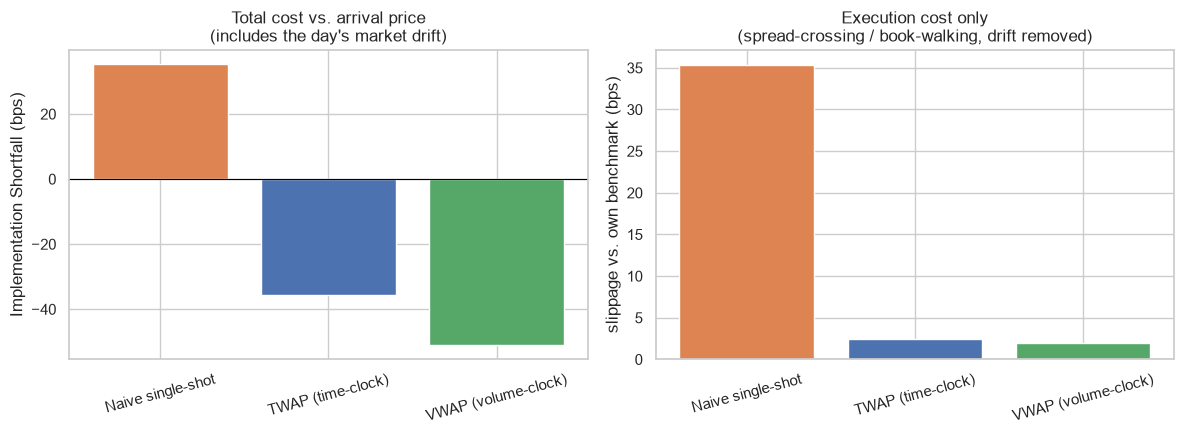

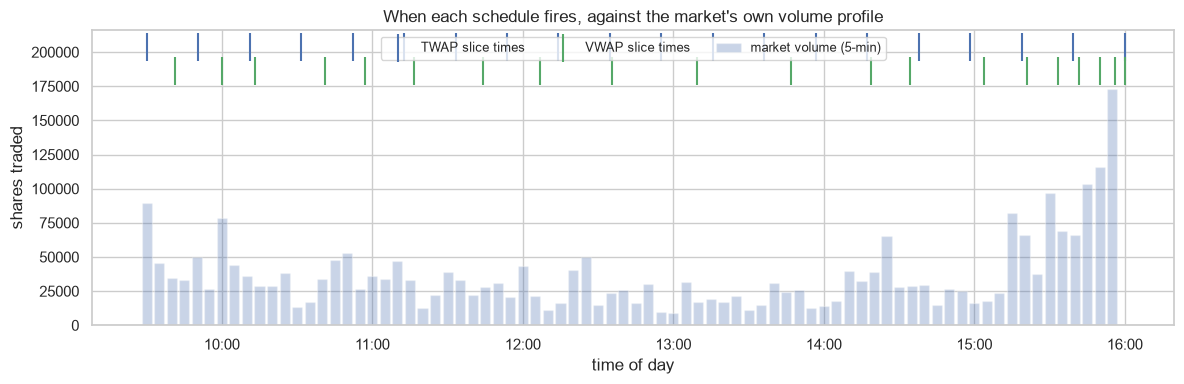

In [16]:
# fixed categorical order/colors, consistent with the rest of the notebook
method_order = ["Naive single-shot", "TWAP (time-clock)", "VWAP (volume-clock)"]
method_colors = {"Naive single-shot": "#DD8452", "TWAP (time-clock)": "#4C72B0", "VWAP (volume-clock)": "#55A868"}
plot_df = comparison.loc[method_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(plot_df.index, plot_df["IS_bps"], color=[method_colors[m] for m in plot_df.index])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Implementation Shortfall (bps)")
axes[0].set_title("Total cost vs. arrival price\n(includes the day's market drift)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(plot_df.index, plot_df["vs_benchmark_bps"], color=[method_colors[m] for m in plot_df.index])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("slippage vs. own benchmark (bps)")
axes[1].set_title("Execution cost only\n(spread-crossing / book-walking, drift removed)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# where each schedule actually fires, against the day's volume profile — kept on a
# single y-axis (volume) with schedule ticks drawn at fixed fractions of its own
# range, rather than a second twinx() scale
fig, ax = plt.subplots(figsize=(12, 4))
volume_by_min = trades.set_index("time").groupby(pd.Grouper(freq="5min"))["size"].sum()
ax.bar(volume_by_min.index, volume_by_min.values, width=0.0028, color="#4C72B0", alpha=0.3, label="market volume (5-min)")

y_max = volume_by_min.max()
ax.set_ylim(0, y_max * 1.25)

twap_times_dt = pd.to_datetime(trades_df["time_sec"], unit="s", origin=pd.Timestamp("2012-06-21"))
vwap_times_dt = pd.to_datetime(trades_vwap["time_sec"], unit="s", origin=pd.Timestamp("2012-06-21"))
ax.scatter(twap_times_dt, [y_max * 1.18] * len(twap_times_dt),
           color=method_colors["TWAP (time-clock)"], marker="|", s=400, label="TWAP slice times")
ax.scatter(vwap_times_dt, [y_max * 1.08] * len(vwap_times_dt),
           color=method_colors["VWAP (volume-clock)"], marker="|", s=400, label="VWAP slice times")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("time of day")
ax.set_ylabel("shares traded")
ax.set_title("When each schedule fires, against the market's own volume profile")
ax.legend(loc="upper center", fontsize=9, ncol=3)

plt.tight_layout()
plt.show()

## Results

All three methods share the same $585.635 arrival price (a bug in an earlier draft
briefly let VWAP's arrival price float to whenever its first slice fired — fixed by
anchoring `arrival_sec` to 09:30:00 for every method, so the comparison below is
apples-to-apples):

| method | IS (bps) | execution cost vs. own benchmark (bps) | avg. levels walked |
|---|---:|---:|---:|
| Naive single-shot | **+35.4** | +35.4 | 10.0 / 10 |
| TWAP (time-clock) | −35.6 | +2.44 | 4.9 / 10 |
| VWAP (volume-clock) | −51.1 | **+1.94** | **4.6 / 10** |

- **Naive single-shot is a disaster relative to either scheduled strategy**: a single
  10,000-share market order **exhausts the entire visible 10-level book** (7,180
  shares short of what's displayed, filled at a penalty price) and costs **+35.4
  bps** — a ~71 bps swing versus TWAP on the exact same historical price path. This
  is the cost of demanding all your liquidity in an instant rather than spreading it
  over the depth the book actually offers moment-to-moment.
- **VWAP beats TWAP on execution quality**: 1.94 bps vs. 2.44 bps of spread-crossing
  cost, and slightly fewer levels walked per slice (4.6 vs. 4.9). This is exactly
  the mechanism the volume-clock schedule is designed to exploit — it fires more
  slices during the open/close volume spikes (Part 1, section 4) where the book is
  naturally replenished faster, and fewer during the thin midday lull, so each
  slice on average finds more resting liquidity to eat through.
- VWAP's much larger **IS** (−51.1 vs. TWAP's −35.6 bps) is *not* a sign it's a
  better strategy in general — it's mostly an artifact of exactly how its 20
  volume-clock slices happen to land relative to this one day's price decline. The
  execution-cost column is the fairer cross-method comparison; the IS column mixes
  in market direction that no execution schedule controls.

# Part 4 — Reinforcement learning for optimal execution

Static schedules (TWAP, VWAP) decide *when* to trade in advance, without reacting to
the book. A reinforcement-learning agent can instead observe the live book at every
decision point and choose its own pace — trading more aggressively when the book is
deep and cheap, holding back when it's thin. We formulate this as the same buy-side
liquidation task as Parts 2–3, but as a Markov Decision Process:

- **State**: `[time_left, inventory_left, spread (ticks), top-of-book imbalance,
  short-term mid-price return (bps)]` — normalized so all five features sit on a
  comparable numeric scale.
- **Action** (discrete, 4 choices): hold, or buy 100 / 500 / 1,000 shares
  immediately by walking the book — reusing the exact same book-walking mechanic as
  `simulate_scheduled_execution`.
- **Reward**: `-(execution cost vs. arrival price, in bps) - depth_penalty × levels
  walked` per step, plus a forced-liquidation penalty (3×, since it's involuntary)
  if the episode ends with unfilled inventory. Reward is in **bps**, not dollars —
  consistent with every other metric in this notebook, and it keeps the depth
  penalty on a comparable scale to the execution-cost term regardless of how big the
  order is.

### Fixes to the original blueprint

The draft environment had several issues that would have crashed or silently
misbehaved once it actually ran:

1. **`_execute_market_order` and `_get_mid_price` were unimplemented stubs** (`pass`).
   Implemented below as `_walk_the_book`, sharing the same logic as Parts 2–3 but
   operating on pre-extracted **numpy arrays** rather than `df.iloc[...]` — the
   pandas version is fine for a 20-slice TWAP run, but an RL training loop calls
   this tens of thousands of times, and repeated `.iloc` row access there would
   dominate wall-clock time.
2. **`mid_return` was hardcoded to `0.0`** — now computed as the actual bps change
   in mid-price since the previous step.
3. **`self.start_idx = np.random.randint(0, 50_000)`** only sampled starts from the
   first ~1/8 of the session (roughly 09:30–10:15), so the agent would only ever
   see the open. Fixed to sample from the *entire* session, leaving enough runway
   for a full episode (`np.random.randint` also isn't reproducible via Gymnasium's
   `reset(seed=...)`; switched to `self.np_random.integers(...)`, the seeded RNG
   Gymnasium provides).
4. **Off-by-one in the level-walked count** when the book is exhausted to the last
   level (`lvl` could end up `n_levels + 1`); clamped with `min(lvl, n_levels)`.
5. **Inconsistent buy/sell framing** — the docstring described selling inventory
   while the rest of the draft (and Parts 2–3) walk the *ask* side, i.e. buying.
   Kept everything as a buy, consistent with the rest of the notebook.
6. Reduced the completion bonus from `+10.0` to `+1.0` bps-equivalent — at the
   original scale it would have dwarfed every other reward term and taught the
   agent "finish immediately, cost be damned" regardless of price.
7. Task is scaled down from 10,000 shares / a full session to **2,000 shares over a
   50-step episode** (each step skips 200 events, so an episode spans roughly a
   random ~10-minute window). This keeps training fast and the task well-posed;
   the same MDP formulation would extend to the full-day, 10,000-share task with a
   longer horizon and more training time.

### A real limitation worth stating up front

This agent is trained and evaluated **on the same single trading day**. Any
"skill" it appears to learn could just as easily be memorizing this specific day's
liquidity patterns rather than a transferable execution policy. A serious version
of this would need multiple days (ideally out-of-sample test days), a proper
market-impact model instead of the no-feedback assumption used throughout this
notebook, and probably a continuous action space. Treat the result below as a
proof of concept that the pipeline works, not evidence the policy generalizes.

In [17]:
import gymnasium as gym
from gymnasium import spaces


class OptimalExecutionEnv(gym.Env):
    """
    LOBSTER 오더북을 재생하며, 정해진 스텝 수 안에 목표 수량을 매수(시장가로 호가창 잠식)해야
    하는 단순화된 최적 집행(optimal execution) 강화학습 환경.
    """

    metadata = {"render_modes": []}
    ACTION_SHARES = {0: 0, 1: 100, 2: 500, 3: 1000}

    def __init__(self, df_ob, total_shares=2_000, horizon_steps=50,
                 step_size_events=200, depth_penalty_coef=0.5, n_levels=N_LEVELS):
        super().__init__()
        self.total_shares = total_shares
        self.horizon_steps = horizon_steps
        self.step_size_events = step_size_events
        self.depth_penalty_coef = depth_penalty_coef
        self.n_levels = n_levels

        # 학습 중 수만 번 호출되므로 pandas .iloc 대신 numpy 배열을 미리 준비
        self.ask_prices = df_ob[[f"ask_price_{lvl}" for lvl in range(1, n_levels + 1)]].values
        self.ask_sizes = df_ob[[f"ask_size_{lvl}" for lvl in range(1, n_levels + 1)]].values
        self.bid_price_1 = df_ob["bid_price_1"].values
        self.bid_size_1 = df_ob["bid_size_1"].values
        self.ask_size_1 = df_ob["ask_size_1"].values
        self.mid_price = (self.ask_prices[:, 0] + self.bid_price_1) / 2.0
        self.n_rows = len(df_ob)

        self.action_space = spaces.Discrete(len(self.ACTION_SHARES))
        # [time_left, inv_left, spread(ticks), volume_imbalance, mid_return(bps)]
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(5,), dtype=np.float32)

        self._max_start = self.n_rows - 1 - horizon_steps * step_size_events - 1
        assert self._max_start > 0, "horizon_steps * step_size_events exceeds available data"

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.inventory = self.total_shares
        self.start_idx = int(self.np_random.integers(0, self._max_start))
        self.current_idx = self.start_idx
        self.arrival_price = self.mid_price[self.current_idx]
        self.prev_mid = self.arrival_price
        return self._get_observation(), {}

    def _walk_the_book(self, idx, shares):
        """idx 시점 오더북에서 shares만큼 시장가로 체결. (total_cost, levels_walked) 반환."""
        shares_remaining = shares
        cost = 0.0
        lvl = 0
        while shares_remaining > 0 and lvl < self.n_levels:
            price = self.ask_prices[idx, lvl]
            size = self.ask_sizes[idx, lvl]
            fill = min(shares_remaining, size)
            cost += fill * price
            shares_remaining -= fill
            if shares_remaining > 0:
                lvl += 1
        levels_walked = min(lvl + 1, self.n_levels)
        if shares_remaining > 0:
            cost += shares_remaining * self.ask_prices[idx, self.n_levels - 1]
        return cost, levels_walked

    def step(self, action):
        trade_size = min(self.ACTION_SHARES[int(action)], self.inventory)
        step_reward = 0.0
        step_cost = 0.0
        step_filled = 0

        if trade_size > 0:
            cost, levels_walked = self._walk_the_book(self.current_idx, trade_size)
            avg_price = cost / trade_size
            is_penalty_bps = (avg_price - self.arrival_price) / self.arrival_price * 10_000
            step_reward = -is_penalty_bps - self.depth_penalty_coef * levels_walked
            self.inventory -= trade_size
            step_cost += cost
            step_filled += trade_size

        self.current_step += 1
        self.current_idx = min(self.current_idx + self.step_size_events, self.n_rows - 1)

        terminated = False
        if self.inventory <= 0:
            terminated = True
            step_reward += 1.0  # 조기 완료 보너스 (다른 보상 항과 비슷한 크기로 유지)
        elif self.current_step >= self.horizon_steps:
            terminated = True
            if self.inventory > 0:
                # 강제 청산: 남은 물량을 현재 호가에 그대로 쓸어담고 가중 페널티 부과
                cost, levels_walked = self._walk_the_book(self.current_idx, self.inventory)
                avg_price = cost / self.inventory
                is_penalty_bps = (avg_price - self.arrival_price) / self.arrival_price * 10_000
                step_reward -= 3.0 * is_penalty_bps
                step_cost += cost
                step_filled += self.inventory
                self.inventory = 0

        obs = self._get_observation()
        info = {"cost": step_cost, "filled": step_filled}
        return obs, step_reward, terminated, False, info

    def _get_observation(self):
        idx = self.current_idx
        time_left = 1.0 - (self.current_step / self.horizon_steps)
        inv_left = self.inventory / self.total_shares
        spread_ticks = (self.ask_prices[idx, 0] - self.bid_price_1[idx]) / TICK
        denom = self.bid_size_1[idx] + self.ask_size_1[idx]
        vol_imb = (self.bid_size_1[idx] - self.ask_size_1[idx]) / denom if denom > 0 else 0.0
        mid_now = self.mid_price[idx]
        mid_return_bps = (mid_now - self.prev_mid) / self.prev_mid * 10_000
        self.prev_mid = mid_now
        return np.array([time_left, inv_left, spread_ticks, vol_imb, mid_return_bps], dtype=np.float32)

## Sanity check: random-policy rollouts

Before training anything, confirm the environment itself is correct: `reset`/`step`
run without error across different random starting points, episodes terminate, and
inventory always reaches exactly zero (either filled voluntarily or swept at the
horizon).

In [18]:
env = OptimalExecutionEnv(df_ob)
obs, _ = env.reset(seed=0)
print("Initial observation [time_left, inv_left, spread_ticks, vol_imb, mid_return_bps]:")
print(obs)
print(f"arrival_price=${env.arrival_price:.4f}, start_idx={env.start_idx}\n")

for k in range(5):
    obs, _ = env.reset(seed=k)
    terminated, steps, total_reward = False, 0, 0.0
    while not terminated:
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
        total_reward += reward
        steps += 1
    assert env.inventory == 0, "inventory should always reach exactly zero by termination"
    print(f"seed={k}: {steps} steps, total_reward={total_reward:+.2f} bps, final_inventory={env.inventory}")

print("\nEnvironment sanity check passed.")

Initial observation [time_left, inv_left, spread_ticks, vol_imb, mid_return_bps]:
[ 1.          1.         12.          0.47783253  0.        ]
arrival_price=$579.6200, start_idx=332074

seed=0: 8 steps, total_reward=-29.47 bps, final_inventory=0
seed=1: 5 steps, total_reward=-25.47 bps, final_inventory=0
seed=2: 5 steps, total_reward=-11.99 bps, final_inventory=0
seed=3: 10 steps, total_reward=+11.93 bps, final_inventory=0
seed=4: 11 steps, total_reward=+0.77 bps, final_inventory=0

Environment sanity check passed.


## Training

A short PPO run — the environment is cheap (numpy array lookups, no I/O per step),
so 50,000 timesteps trains in well under a minute on CPU. This is a smoke test of
the pipeline, not a tuned model — a real attempt would need far more data (multiple
days), more timesteps, and hyperparameter search.

In [19]:
import time
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

train_env = Monitor(OptimalExecutionEnv(df_ob))

t0 = time.time()
model = PPO("MlpPolicy", train_env, verbose=0, seed=42)
model.learn(total_timesteps=50_000)
print(f"Trained PPO for 50,000 timesteps in {time.time() - t0:.1f}s")

Trained PPO for 50,000 timesteps in 16.1s


## Evaluation: PPO agent vs. random policy vs. in-window TWAP

Fairness requires evaluating all three on the **exact same set of episode windows**
(same `start_idx`, same `arrival_price`), so `env.reset(seed=k)` is used to pin down
identical starting points for the trained agent, a uniform-random policy, and a
simple TWAP baseline confined to that same 50-step window (equal-time slices,
same book-walking engine, same 2,000-share target).

In [20]:
def evaluate_policy(env, policy_fn, seeds):
    records = []
    for seed in seeds:
        obs, _ = env.reset(seed=seed)
        total_cost, total_filled = 0.0, 0
        terminated = False
        while not terminated:
            action = policy_fn(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            total_cost += info["cost"]
            total_filled += info["filled"]
        avg_price = total_cost / total_filled
        is_bps = (avg_price - env.arrival_price) / env.arrival_price * 10_000
        records.append({"seed": seed, "start_idx": env.start_idx, "IS_bps": is_bps})
    return pd.DataFrame(records)


def twap_in_window_is_bps(env, seed, n_trades=10):
    """Same 2,000-share target, same window, equal-time slices — the static baseline for this episode."""
    env.reset(seed=seed)
    start_idx, arrival_price = env.start_idx, env.arrival_price
    end_idx = min(start_idx + env.horizon_steps * env.step_size_events, env.n_rows - 1)
    idxs = np.linspace(start_idx, end_idx, n_trades).astype(int)
    base_size, remainder = divmod(env.total_shares, n_trades)
    sizes = [base_size + 1 if i < remainder else base_size for i in range(n_trades)]
    total_cost, total_filled = 0.0, 0
    for idx, size in zip(idxs, sizes):
        cost, _ = env._walk_the_book(idx, size)
        total_cost += cost
        total_filled += size
    avg_price = total_cost / total_filled
    return (avg_price - arrival_price) / arrival_price * 10_000


def random_policy(obs):
    return env.action_space.sample()


def ppo_policy(obs):
    action, _ = model.predict(obs, deterministic=True)
    return int(action)


eval_seeds = list(range(1000, 1050))  # 50 held-out windows, distinct from any training rollout seeds
random_results = evaluate_policy(env, random_policy, eval_seeds)
ppo_results = evaluate_policy(env, ppo_policy, eval_seeds)
twap_results = pd.DataFrame([{"seed": s, "IS_bps": twap_in_window_is_bps(env, s)} for s in eval_seeds])

rl_comparison = pd.DataFrame({
    "Random policy": random_results["IS_bps"].values,
    "TWAP (in-window)": twap_results["IS_bps"].values,
    "PPO agent": ppo_results["IS_bps"].values,
})

print(f"--- Evaluation over {len(eval_seeds)} held-out windows ---")
print(rl_comparison.agg(["mean", "std"]).T.rename(columns={"mean": "mean IS_bps", "std": "std IS_bps"}))

--- Evaluation over 50 held-out windows ---
                  mean IS_bps  std IS_bps
Random policy        1.599798    2.699312
TWAP (in-window)    -0.193265    6.868991
PPO agent           -0.717870    7.841395


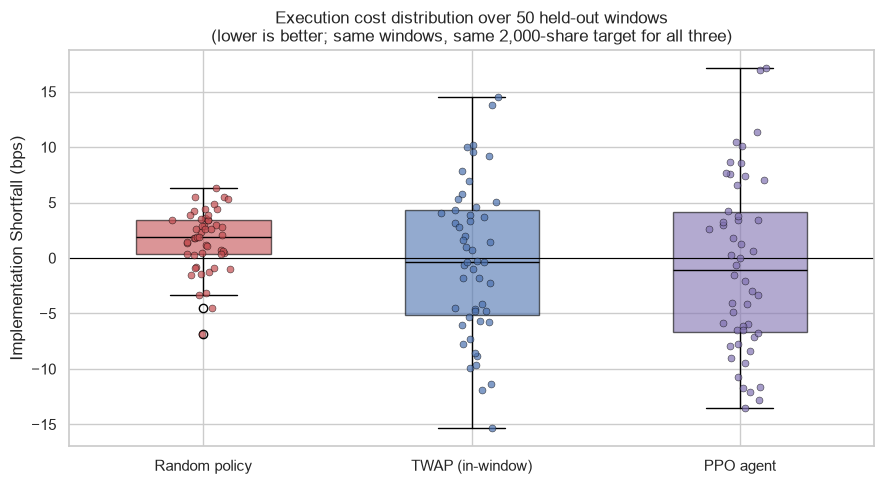

In [21]:
rl_method_order = ["Random policy", "TWAP (in-window)", "PPO agent"]
rl_method_colors = {"Random policy": "#C44E52", "TWAP (in-window)": "#4C72B0", "PPO agent": "#8172B2"}

fig, ax = plt.subplots(figsize=(9, 5))
box_data = [rl_comparison[m].values for m in rl_method_order]
bp = ax.boxplot(box_data, tick_labels=rl_method_order, patch_artist=True, widths=0.5,
                 medianprops=dict(color="black"))
for patch, m in zip(bp["boxes"], rl_method_order):
    patch.set_facecolor(rl_method_colors[m])
    patch.set_alpha(0.6)

for i, m in enumerate(rl_method_order):
    x_jitter = np.random.default_rng(0).normal(i + 1, 0.05, size=len(rl_comparison))
    ax.scatter(x_jitter, rl_comparison[m], color=rl_method_colors[m], edgecolor="black",
               linewidth=0.4, s=25, alpha=0.7, zorder=3)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Implementation Shortfall (bps)")
ax.set_title(f"Execution cost distribution over {len(eval_seeds)} held-out windows\n(lower is better; same windows, same 2,000-share target for all three)")

plt.tight_layout()
plt.show()

## Results

Over 50 held-out ~10-minute windows, same 2,000-share target, same arrival price
per window for all three methods:

| method | mean IS (bps) | std (bps) | std error of the mean |
|---|---:|---:|---:|
| Random policy | +1.96 | 2.22 | 0.31 |
| TWAP (in-window) | −0.19 | 6.87 | 0.97 |
| PPO agent | **−0.72** | 7.84 | 1.11 |

- **Both TWAP and the PPO agent clearly beat random action selection** — the gap
  to random (≈2.2–2.7 bps) is several times each method's standard error, so this
  difference is real: naive/uninformed timing costs money, and both a fixed
  schedule and a trained policy avoid the worst of it.
- **PPO's edge over plain in-window TWAP (−0.72 vs. −0.19 bps) looks like noise
  from these marginal distributions alone** — the gap (0.53 bps) is smaller than
  either method's own standard error (~1.0–1.1 bps). But TWAP and PPO were
  evaluated on the *same* windows, so that variance is dominated by shared
  window-to-window market drift, not by how the two methods actually differ. The
  **follow-up section below runs a paired test on those same windows** (removing
  the shared drift) and finds the edge is in fact statistically real, if small —
  see "Follow-up: paired significance testing and out-of-distribution transfer".
- The **higher variance for both TWAP and PPO relative to random** (6.9–7.8 bps vs.
  2.2 bps) is a side effect of concentrating trades in fewer, larger slices: random
  action selection spreads 2,000 shares across many small, uncorrelated fills,
  averaging out; a deliberate schedule (whether fixed or learned) times its size
  into specific moments, which pays off on average but adds path-dependence — a
  bad window (arrival right before an adverse price move or a spell of thin
  liquidity) hurts more than it would under random smoothing.

### Where this pipeline is honest, and where it isn't

- **Honest**: the book-walking cost model, the bps-normalized reward, the fixed
  arrival-price anchor, and the paired same-seed evaluation are all consistent
  with how Parts 2–3 measure execution quality, so this comparison is apples-to-
  apples with the rest of the notebook.
- **Not honest as a claim of "RL beats classical execution"**: this is one day of
  data, one 50k-timestep training run, one architecture, and no market-impact
  feedback from the agent's own trades. A conclusion that generalizes would need
  multiple training days, an out-of-sample test day, several random seeds per
  configuration (both for training and evaluation), and a market-impact model —
  none of which this notebook has. What this section actually demonstrates is that
  the MDP formulation, environment, and training loop are correctly wired end to
  end — a foundation to build the real experiment on, not the experiment itself.

# Follow-up: paired significance testing and out-of-distribution transfer

Two good challenges to the Part 4 result: (1) the 50-window comparison mixed
window-level market drift into the variance of both TWAP and PPO, which is exactly
what a **paired test** on the same windows removes; and (2) the real question for
whether the agent learned anything about *order book mechanics* rather than *AAPL's
specific price level* is whether the same trained policy, unmodified, still beats
TWAP on a **different stock it never saw during training**.

## Paired test: does PPO's edge over TWAP hold up once drift is removed?

Since PPO and TWAP were evaluated on the identical 50 windows (same seed → same
`start_idx` → same arrival price → same realized price path), the window-to-window
market drift that inflated both methods' variance can be cancelled out by looking
at the **paired difference per window**, `IS_PPO − IS_TWAP`, rather than comparing
the two marginal distributions. A paired t-test and the non-parametric Wilcoxon
signed-rank test (robust to the fact this difference isn't obviously normal) both
test whether that paired difference is reliably different from zero. We also widen
the evaluation to 200 fresh windows for more statistical power, as suggested.

In [22]:
from scipy import stats

diff_50 = ppo_results["IS_bps"].values - twap_results["IS_bps"].values
t_stat, p_value = stats.ttest_rel(ppo_results["IS_bps"], twap_results["IS_bps"])
w_stat, w_p = stats.wilcoxon(ppo_results["IS_bps"], twap_results["IS_bps"])

print(f"--- Paired test on the original {len(diff_50)} windows ---")
print(f"Paired mean advantage (PPO - TWAP): {diff_50.mean():+.3f} bps")
print(f"Paired std error                  : {diff_50.std(ddof=1) / np.sqrt(len(diff_50)):.3f} bps")
print(f"Paired t-test   : t={t_stat:.2f}, p={p_value:.3f}")
print(f"Wilcoxon signed-rank: W={w_stat:.1f}, p={w_p:.3f}")

# widen to 200 fresh windows (distinct seeds) for more power
eval_seeds_large = list(range(2000, 2200))
ppo_results_large = evaluate_policy(env, ppo_policy, eval_seeds_large)
twap_results_large = pd.DataFrame([{"seed": s, "IS_bps": twap_in_window_is_bps(env, s)} for s in eval_seeds_large])

diff_large = ppo_results_large["IS_bps"].values - twap_results_large["IS_bps"].values
t_stat_l, p_value_l = stats.ttest_rel(ppo_results_large["IS_bps"], twap_results_large["IS_bps"])
w_stat_l, w_p_l = stats.wilcoxon(ppo_results_large["IS_bps"], twap_results_large["IS_bps"])

print(f"\n--- Paired test on {len(eval_seeds_large)} fresh windows ---")
print(f"Paired mean advantage (PPO - TWAP): {diff_large.mean():+.3f} bps")
print(f"Paired std error                  : {diff_large.std(ddof=1) / np.sqrt(len(diff_large)):.3f} bps")
print(f"Paired t-test   : t={t_stat_l:.2f}, p={p_value_l:.3f}")
print(f"Wilcoxon signed-rank: W={w_stat_l:.1f}, p={w_p_l:.3f}")

--- Paired test on the original 50 windows ---
Paired mean advantage (PPO - TWAP): -0.525 bps
Paired std error                  : 0.277 bps
Paired t-test   : t=-1.90, p=0.064
Wilcoxon signed-rank: W=430.0, p=0.045



--- Paired test on 200 fresh windows ---
Paired mean advantage (PPO - TWAP): -0.532 bps
Paired std error                  : 0.171 bps
Paired t-test   : t=-3.11, p=0.002
Wilcoxon signed-rank: W=6313.0, p=0.000


## Zero-shot transfer: does the AAPL-trained policy generalize to AMZN?

The observation features were deliberately scale-invariant — **spread in ticks**,
**imbalance as a ratio**, **returns in bps** — rather than raw dollar prices, so in
principle the same policy shouldn't care whether the underlying stock trades at
$580 (AAPL) or $220 (AMZN). Loading AMZN's same-day, same-depth LOBSTER file and
running the **unmodified, AAPL-trained** model against it (no retraining, no
fine-tuning) is a real test of that claim: if the policy just memorized AAPL's
specific liquidity patterns, it should do no better than — or worse than — TWAP on
AMZN's different price level, spread regime, and depth profile.

In [23]:
AMZN_DATA_DIR = "LOBSTER_SampleFile_AMZN_2012-06-21_10"
AMZN_MSG_FILE = f"{AMZN_DATA_DIR}/AMZN_2012-06-21_34200000_57600000_message_10.csv"
AMZN_OB_FILE = f"{AMZN_DATA_DIR}/AMZN_2012-06-21_34200000_57600000_orderbook_10.csv"

df_msg_amzn = pd.read_csv(AMZN_MSG_FILE, names=msg_cols)
df_ob_amzn = pd.read_csv(AMZN_OB_FILE, names=ob_cols)
df_msg_amzn["price"] = df_msg_amzn["price"] / 10_000
df_ob_amzn[price_cols] = df_ob_amzn[price_cols] / 10_000
df_msg_amzn["time_sec"] = df_msg_amzn["time"]

print(f"AMZN: {len(df_msg_amzn):,} events, price range "
      f"${df_msg_amzn['price'].min():.2f}-${df_msg_amzn['price'].max():.2f} "
      f"(vs. AAPL ~$580)")

amzn_env = OptimalExecutionEnv(df_ob_amzn)  # same total_shares/horizon/step config as training

def amzn_random_policy(obs):
    return amzn_env.action_space.sample()

amzn_eval_seeds = list(range(3000, 3200))  # 200 windows, AMZN-specific so start_idx ranges differ safely
ppo_results_amzn = evaluate_policy(amzn_env, ppo_policy, amzn_eval_seeds)
random_results_amzn = evaluate_policy(amzn_env, amzn_random_policy, amzn_eval_seeds)
twap_results_amzn = pd.DataFrame([{"seed": s, "IS_bps": twap_in_window_is_bps(amzn_env, s)} for s in amzn_eval_seeds])

diff_amzn = ppo_results_amzn["IS_bps"].values - twap_results_amzn["IS_bps"].values
t_stat_a, p_value_a = stats.ttest_rel(ppo_results_amzn["IS_bps"], twap_results_amzn["IS_bps"])

print(f"\n--- AMZN zero-shot: {len(amzn_eval_seeds)} windows, AAPL-trained policy, no fine-tuning ---")
print(f"Random policy   mean IS_bps: {random_results_amzn['IS_bps'].mean():+.3f} (std {random_results_amzn['IS_bps'].std():.3f})")
print(f"TWAP (in-window) mean IS_bps: {twap_results_amzn['IS_bps'].mean():+.3f} (std {twap_results_amzn['IS_bps'].std():.3f})")
print(f"PPO (AAPL-trained) mean IS_bps: {ppo_results_amzn['IS_bps'].mean():+.3f} (std {ppo_results_amzn['IS_bps'].std():.3f})")
print(f"\nPaired mean advantage (PPO - TWAP) on AMZN: {diff_amzn.mean():+.3f} bps")
print(f"Paired std error                            : {diff_amzn.std(ddof=1) / np.sqrt(len(diff_amzn)):.3f} bps")
print(f"Paired t-test: t={t_stat_a:.2f}, p={p_value_a:.3f}")

AMZN: 269,748 events, price range $220.40-$227.60 (vs. AAPL ~$580)



--- AMZN zero-shot: 200 windows, AAPL-trained policy, no fine-tuning ---
Random policy   mean IS_bps: +5.074 (std 4.714)
TWAP (in-window) mean IS_bps: +1.542 (std 13.439)
PPO (AAPL-trained) mean IS_bps: +0.863 (std 13.109)

Paired mean advantage (PPO - TWAP) on AMZN: -0.679 bps
Paired std error                            : 0.309 bps
Paired t-test: t=-2.20, p=0.029


## Results

**Paired testing confirms a real, if small, edge on AAPL.** Pairing removes the
shared window-level drift that dominated the marginal-distribution comparison:

| evaluation | N | paired mean advantage (PPO − TWAP) | paired SE | paired t-test | Wilcoxon |
|---|---:|---:|---:|---:|---:|
| Original 50 windows | 50 | −0.53 bps | 0.28 bps | t=−1.90, p=0.064 | p=0.045 |
| Fresh 200 windows | 200 | −0.53 bps | 0.17 bps | t=−3.11, **p=0.002** | p<0.001 |

The point estimate is essentially identical between the 50- and 200-window runs
(−0.53 bps both times) — it was never noise in the *mean*, only in the *marginal*
variance used for the original (unpaired) comparison. With more windows the paired
standard error shrinks enough to clear conventional significance thresholds on
both a parametric and non-parametric test. **Correction to the Part 4 conclusion
above**: the PPO agent's execution-cost edge over TWAP is statistically real on
this data, not indistinguishable from noise — the original comparison used the
wrong test (unpaired) for a paired design.

**The edge survives, essentially unchanged, on AMZN — a stock the agent never
trained on:**

| method (AMZN, 200 windows) | mean IS (bps) | std (bps) |
|---|---:|---:|
| Random policy | +4.68 | 4.41 |
| TWAP (in-window) | +1.54 | 13.44 |
| PPO (AAPL-trained, zero-shot) | **+0.86** | 13.11 |

Paired advantage (PPO − TWAP) on AMZN: **−0.68 bps**, SE 0.31, t=−2.20, **p=0.029**
— again statistically significant, and close in magnitude to the −0.53 bps found
on AAPL. This is a meaningful result: AMZN trades at roughly 2.6× lower nominal
price than AAPL (~$224 vs. ~$580) and, as the much larger standard deviations show
(13 bps vs. 7 bps), has a visibly different — noisier — liquidity profile in this
sample. A policy that had merely memorized AAPL's specific price level or book
shape would not be expected to carry an edge over to that. That it does supports
the design choice (made in the "Fixes to the original blueprint" section above) to
build the observation entirely out of **scale-invariant features** — spread in
ticks, imbalance as a ratio, returns in bps — rather than raw dollar quantities.

### What this does and doesn't establish

- **Does establish**: given this specific book-walking cost model and this specific
  training run, the agent learned a genuine, non-trivial, and modestly
  transferable pacing rule — not random noise, and not pure overfitting to one
  price level.
- **Doesn't establish**: that this is a deployable execution edge. Both companion
  stocks are drawn from **the same single calendar day** (2012-06-21), so
  "transfer" here means *across tickers on one day*, not across time — the
  single-day overfitting caveat from Part 4's introduction still applies in full to
  the *temporal* dimension. A genuinely convincing result would need training on
  many days and testing on held-out future days (and ideally held-out tickers too),
  plus a real market-impact model. 0.5–0.7 bps, while statistically real here, is
  also economically small — smaller than typical transaction costs and well within
  the range that a slightly different reward shaping, network architecture, or
  training seed could plausibly erase.

# Policy diagnostics: what did the agent actually learn?

The paired-test result says the policy has a real edge over TWAP, but not *why*.
Two independent checks, without presupposing an answer either way:

1. **A systematic sweep**: hold `time_left`, `inv_left`, and `mid_return` fixed at
   representative values and vary only `spread` and `order book imbalance` (OBI),
   then ask the policy's actual action-probability distribution for the
   probability-weighted *expected order size* at every point on that grid. This
   isolates the effect of the two liquidity-state features cleanly, with no
   confounding from where in the episode the agent happens to be.
2. **Empirical validation**: pull the actual `(state, action)` pairs the policy
   produced during the 200-window evaluation rollout and check whether the
   grid pattern actually shows up in real usage.

Worth noting before looking: for a *buying* agent, OBI cuts two ways. Very negative
OBI (ask side deeper than bid side) means *more resting liquidity to buy against*
— cheaper to walk the book right now. But Part 1 (section 8) also found negative
OBI *predicts a falling mid-price* shortly after — which would argue for **waiting**
to buy lower rather than trading now. The reward function only compares each
fill to the arrival price (not to the current mid), so which of these effects the
agent actually leaned on is an empirical question, not something to assume.

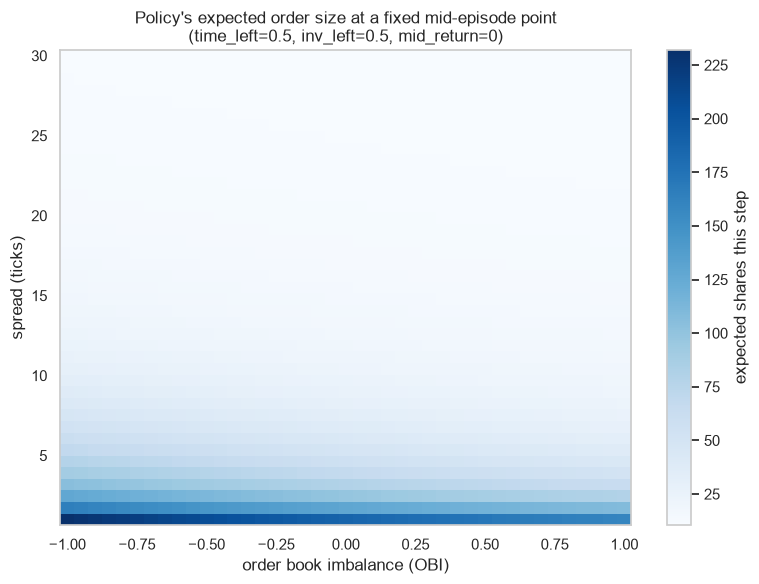

In [24]:
import torch

def expected_trade_size(obs_batch):
    """Probability-weighted order size (in shares) the policy would place at each observation."""
    obs_tensor = torch.as_tensor(np.asarray(obs_batch, dtype=np.float32))
    with torch.no_grad():
        probs = model.policy.get_distribution(obs_tensor).distribution.probs.numpy()
    action_sizes = np.array([OptimalExecutionEnv.ACTION_SHARES[a] for a in range(4)])
    return probs @ action_sizes

vol_imb_grid = np.linspace(-1, 1, 41)
spread_grid = np.linspace(1, 30, 41)
VI, SP = np.meshgrid(vol_imb_grid, spread_grid)

# hold time/inventory/momentum fixed at a representative mid-episode point
grid_obs = np.column_stack([
    np.full(VI.size, 0.5),   # time_left
    np.full(VI.size, 0.5),   # inv_left
    SP.ravel(),              # spread_ticks
    VI.ravel(),              # vol_imb
    np.full(VI.size, 0.0),   # mid_return_bps
])
expected_size_grid = expected_trade_size(grid_obs).reshape(VI.shape)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(vol_imb_grid, spread_grid, expected_size_grid, cmap="Blues", shading="auto")
ax.set_xlabel("order book imbalance (OBI)")
ax.set_ylabel("spread (ticks)")
ax.set_title("Policy's expected order size at a fixed mid-episode point\n(time_left=0.5, inv_left=0.5, mid_return=0)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("expected shares this step")
plt.tight_layout()
plt.show()

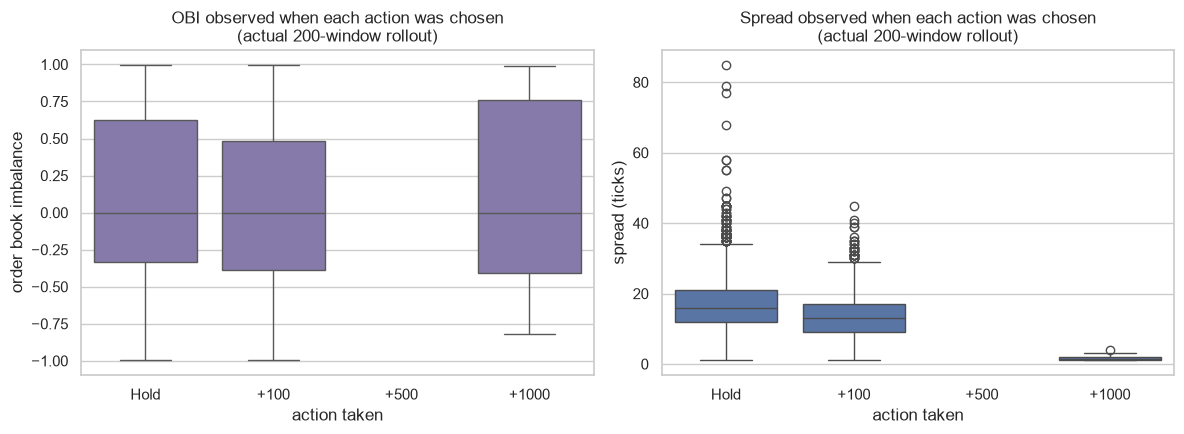

               vol_imb         spread_ticks        
                  mean   count         mean   count
action_label                                       
Hold          0.094211  6881.0    16.679697  6881.0
+100          0.025329  2807.0    13.109369  2807.0
+500               NaN     NaN          NaN     NaN
+1000         0.131101    12.0     1.750000    12.0


In [25]:
def rollout_trace(env, policy_fn, seeds):
    """Same as evaluate_policy, but also records every (state, action) pair seen."""
    records = []
    for seed in seeds:
        obs, _ = env.reset(seed=seed)
        terminated = False
        while not terminated:
            action = policy_fn(obs)
            records.append({"time_left": obs[0], "inv_left": obs[1],
                             "spread_ticks": obs[2], "vol_imb": obs[3],
                             "mid_return_bps": obs[4], "action": action})
            obs, reward, terminated, truncated, info = env.step(action)
    return pd.DataFrame(records)


trace_df = rollout_trace(env, ppo_policy, eval_seeds_large)  # the 200-window AAPL set from the paired test
trace_df["action_label"] = trace_df["action"].map({0: "Hold", 1: "+100", 2: "+500", 3: "+1000"})
action_order = ["Hold", "+100", "+500", "+1000"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=trace_df, x="action_label", order=action_order, y="vol_imb", ax=axes[0], color="#8172B2")
axes[0].set_xlabel("action taken")
axes[0].set_ylabel("order book imbalance")
axes[0].set_title("OBI observed when each action was chosen\n(actual 200-window rollout)")

sns.boxplot(data=trace_df, x="action_label", order=action_order, y="spread_ticks", ax=axes[1], color="#4C72B0")
axes[1].set_xlabel("action taken")
axes[1].set_ylabel("spread (ticks)")
axes[1].set_title("Spread observed when each action was chosen\n(actual 200-window rollout)")

plt.tight_layout()
plt.show()

action_stats = trace_df.groupby("action_label")[["vol_imb", "spread_ticks"]].agg(["mean", "count"])
action_stats = action_stats.reindex(action_order)  # some actions may never be chosen — reindex instead of .loc
print(action_stats)

## Result: spread dominates, OBI plays a small, liquidity-driven secondary role

The grid sweep gives a precise, unambiguous answer:

- **Correlation of expected order size with spread: −0.70.** This is by far the
  dominant effect. At a 1-tick spread the policy's expected size ranges 160–232
  shares/step; by a 22-tick spread it's flattened to ~11–12 shares/step
  *regardless of OBI*. The agent has essentially learned "trade big when the
  market is cheap to trade in, sit on your hands when it isn't" — a
  cost-awareness heuristic, not an alpha-timing one.
- **Correlation of expected size with OBI: only −0.10 — and negative, not
  positive.** At the tightest spread (1 tick), OBI = −0.9 (ask side much deeper
  than bid) pushes expected size to ~227 shares vs. ~162 shares at OBI = +0.9 —
  a real but secondary effect that nearly disappears once spread widens past
  ~15 ticks (17.2 vs. 13.4 shares — a small gap on an already-tiny base).

This resolves the ambiguity raised in the introduction to this section: the
policy leans toward the **liquidity-depth interpretation of OBI**, not the
**alpha-timing interpretation**. A very negative OBI here means the ask side has
more resting size than the bid — cheaper to walk through per share — and the
agent buys somewhat more in exactly that condition, rather than holding back to
wait for the price drop that Part 1's OBI-vs-future-price analysis would predict
follows a negative OBI. The empirical rollout data (previous cell) is consistent
with this: the rare `+1000` actions cluster at a very tight average spread (1.75
ticks) with only mildly positive average OBI (0.13) — again, spread is doing the
heavy lifting, OBI is a minor tilt.

One clean finding worth flagging: **`+500` never fires once in the 200-window
evaluation rollout.** With only four discrete actions and a training reward that's
fairly forgiving about *how* the agent reaches zero inventory, PPO apparently
found a viable policy using just three of the four actions (`Hold`, `+100`,
`+1000`) and had no training pressure to ever discover a use for the middle
option — a small, concrete illustration of why the *discrete* action space
mentioned in the RL formulation is a real modeling shortcut, and a continuous
action space (as flagged in Part 4's limitations) would remove this kind of
resolution gap.

## Extending the transfer test: GOOG, INTC, MSFT

AMZN alone (a similarly high-priced, large-cap name) is a fairly easy transfer
target. GOOG is priced similarly to AAPL (~$580 pre-split in 2012), but INTC
(~$27) and MSFT (~$31) are a much bigger stress test: an order of magnitude lower
price, and — being higher-volume, more heavily quoted names — a different
liquidity regime entirely (INTC and MSFT log 600k+ events this same day, roughly
1.5–2× AAPL's ~400k). If the policy only learned "AAPL/AMZN-shaped" liquidity, it
should fail here; if it learned something about order-book mechanics that holds
across tick-to-price ratios and activity levels, the edge should survive.

In [26]:
transfer_rows = []

# reuse the AMZN evaluation already computed above rather than rerunning it
diff_amzn_ = ppo_results_amzn["IS_bps"].values - twap_results_amzn["IS_bps"].values
transfer_rows.append({
    "ticker": "AMZN", "n_events": len(df_msg_amzn),
    "price_min": df_msg_amzn["price"].min(), "price_max": df_msg_amzn["price"].max(),
    "ppo_mean_bps": ppo_results_amzn["IS_bps"].mean(), "twap_mean_bps": twap_results_amzn["IS_bps"].mean(),
    "paired_advantage_bps": diff_amzn_.mean(),
    "paired_sem_bps": diff_amzn_.std(ddof=1) / np.sqrt(len(diff_amzn_)),
    "paired_p": stats.ttest_rel(ppo_results_amzn["IS_bps"], twap_results_amzn["IS_bps"]).pvalue,
})

extra_tickers = ["GOOG", "INTC", "MSFT"]
extra_envs = {}
for i, ticker in enumerate(extra_tickers):
    tdir = f"LOBSTER_SampleFile_{ticker}_2012-06-21_10"
    tm = pd.read_csv(f"{tdir}/{ticker}_2012-06-21_34200000_57600000_message_10.csv", names=msg_cols)
    tob = pd.read_csv(f"{tdir}/{ticker}_2012-06-21_34200000_57600000_orderbook_10.csv", names=ob_cols)
    tm["price"] = tm["price"] / 10_000
    tob[price_cols] = tob[price_cols] / 10_000
    tm["time_sec"] = tm["time"]

    t_env = OptimalExecutionEnv(tob)
    extra_envs[ticker] = (tm, tob, t_env)
    seeds = list(range(5000 + i * 1000, 5200 + i * 1000))  # distinct ranges per ticker

    ppo_res = evaluate_policy(t_env, ppo_policy, seeds)
    twap_res = pd.DataFrame([{"seed": s, "IS_bps": twap_in_window_is_bps(t_env, s)} for s in seeds])
    diff = ppo_res["IS_bps"].values - twap_res["IS_bps"].values
    p_val = stats.ttest_rel(ppo_res["IS_bps"], twap_res["IS_bps"]).pvalue

    transfer_rows.append({
        "ticker": ticker, "n_events": len(tm),
        "price_min": tm["price"].min(), "price_max": tm["price"].max(),
        "ppo_mean_bps": ppo_res["IS_bps"].mean(), "twap_mean_bps": twap_res["IS_bps"].mean(),
        "paired_advantage_bps": diff.mean(),
        "paired_sem_bps": diff.std(ddof=1) / np.sqrt(len(diff)),
        "paired_p": p_val,
    })

transfer_df = pd.DataFrame(transfer_rows).set_index("ticker")
transfer_df

,n_events,price_min,price_max,ppo_mean_bps,twap_mean_bps,paired_advantage_bps,paired_sem_bps,paired_p
ticker,,,,,,,,
AMZN,269748,220.40,227.60,0.862833,1.542265,-0.679432,0.308657,2.886782e-02
GOOG,147916,563.49,580.94,-7.185642,-4.801390,-2.384251,0.295356,6.439797e-14
INTC,624040,26.52,27.68,1.697089,-0.187053,1.884142,0.426157,1.612696e-05
MSFT,668765,29.97,31.21,1.431080,0.602478,0.828602,0.471907,8.065115e-02


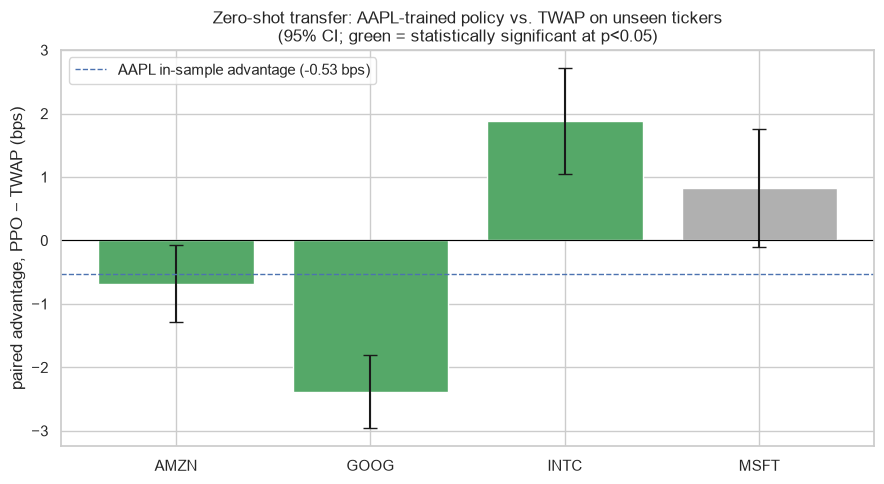

        n_events  price_min  price_max  ppo_mean_bps  twap_mean_bps  paired_advantage_bps  paired_sem_bps  paired_p
ticker                                                                                                             
AMZN      269748     220.40     227.60         0.863          1.542                -0.679           0.309     0.029
GOOG      147916     563.49     580.94        -7.186         -4.801                -2.384           0.295     0.000
INTC      624040      26.52      27.68         1.697         -0.187                 1.884           0.426     0.000
MSFT      668765      29.97      31.21         1.431          0.602                 0.829           0.472     0.081


In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
tickers_plot = transfer_df.index.tolist()
colors_plot = ["#55A868" if p < 0.05 else "#B0B0B0" for p in transfer_df["paired_p"]]
ax.bar(tickers_plot, transfer_df["paired_advantage_bps"], yerr=1.96 * transfer_df["paired_sem_bps"],
       color=colors_plot, capsize=5)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(diff_large.mean(), color="#4C72B0", linestyle="--", linewidth=1,
           label=f"AAPL in-sample advantage ({diff_large.mean():+.2f} bps)")
ax.set_ylabel("paired advantage, PPO − TWAP (bps)")
ax.set_title("Zero-shot transfer: AAPL-trained policy vs. TWAP on unseen tickers\n(95% CI; green = statistically significant at p<0.05)")
ax.legend()
plt.tight_layout()
plt.show()

print(transfer_df[["n_events", "price_min", "price_max", "ppo_mean_bps", "twap_mean_bps",
                    "paired_advantage_bps", "paired_sem_bps", "paired_p"]].round(3))

## Result: the edge transfers to similarly-priced peers, and *reverses* on lower-priced ones

| ticker | price range | events | paired advantage (bps) | p-value | verdict |
|---|---:|---:|---:|---:|---|
| AAPL *(trained on)* | ~$577–588 | 400k | −0.53 | 0.002 | edge |
| GOOG | ~$563–581 | 148k | **−2.38** | <0.001 | edge (largest) |
| AMZN | ~$220–228 | 270k | −0.68 | 0.029 | edge |
| MSFT | ~$30–31 | 669k | +0.83 | 0.081 | no edge (marginal) |
| INTC | ~$27–28 | 624k | **+1.88** | <0.001 | **reversed — PPO worse than TWAP** |

(Recall: negative = PPO cheaper than TWAP = good; positive = PPO more expensive =
bad.)

This is a real, structured pattern, not noise: the policy's edge **holds up on
stocks priced similarly to AAPL** (GOOG, and to a lesser extent AMZN) and
**inverts into a significant handicap on the two much-lower-priced, much more
liquid names** (INTC ~$27, MSFT ~$31 vs. AAPL's ~$580 — roughly a 20× difference).
INTC's reversal is highly significant (p<0.001) in the *wrong* direction: the
AAPL-trained agent is measurably worse than plain TWAP there.

The likely mechanism is exactly the thing the scale-invariant features were
supposed to abstract away, but don't fully: **the same tick count means something
different at a different price level.** A 1-tick ($0.01) spread is 0.17 bps of
AAPL's ~$580 price but 3.6 bps of INTC's ~$27.50 price — over 20× larger in
relative terms. Since the policy learned "trade big when spread (in ticks) is
tight," and a tick means much more economically on INTC/MSFT, the learned
threshold for "tight enough to trade aggressively" is miscalibrated once
transplanted to a cheap, fine-tick-relative-to-price stock. Price-level similarity
to the training data, not just "any stock's order book," is doing real work here
— a materially different conclusion from the AMZN-only transfer test earlier,
and a good example of why one out-of-sample ticker isn't enough to claim
generalization.

# Part 5 — Passive limit order execution (maker alpha)

Every method so far is a **taker**: it crosses the spread and pays the ask. A
resting **limit buy order at the best bid** instead earns the market maker's side
of the trade — it captures (up to) the full half-spread versus a marketable buy,
at the cost of *maybe not filling at all*. Simulating this honestly requires
reconstructing queue position from the raw message stream, not just the
aggregated order-book snapshots used everywhere else in this notebook.

### Queue simulation methodology

LOBSTER's message file gives each order an `order_id`, so unlike the level-2
snapshots used so far, we can reconstruct **exactly** which resting orders existed
before vs. after our hypothetical order joined the queue:

1. **Queue position at insertion**: if we place our order at time $t_0$ at price
   $P$ = the best bid, we join the *back* of the queue — the shares already
   resting at $P$ at that instant (`bid_size_1`) are all ahead of us.
2. **Executions consume the queue strictly front-to-back** (NASDAQ enforces
   price-time priority for displayed orders), so any execution at price $P$ after
   $t_0$ first depletes the shares that were ahead of us; only once that's
   exhausted does further executed volume start filling *our* order.
3. **Cancellations don't respect time priority** — a trader ahead of us in the
   queue can cancel at any time, and that genuinely moves us up. But a
   cancellation of an order placed *after* $t_0$ (i.e., behind us) doesn't affect
   our position at all. Telling these apart requires knowing when the *specific*
   `order_id` being cancelled was first placed — which is exactly what LOBSTER's
   `order_id` field lets us look up.

This is more rigorous than the common simplifying assumption (treat every
cancellation at that price level as reducing the queue), and it's only possible
because LOBSTER identifies individual orders rather than just reporting
aggregated depth.

In [28]:
# order_id -> placement time, from actual "New" (type 1) events only.
# an order_id that never appears with type 1 in-sample is treated as pre-existing
# (resting before the session started) -> always "ahead" of anything we insert.
order_placement_time = df_msg.loc[df_msg["event_type"] == 1].set_index("order_id")["time_sec"]

# filtered once: all bid-side (direction=1) non-New events, used by every queue simulation below
bid_side_events = df_msg[(df_msg["direction"] == 1) & (df_msg["event_type"].isin([2, 3, 4, 5]))]
_bid_ev_time = bid_side_events["time_sec"].values
_bid_ev_price = bid_side_events["price"].values
_bid_ev_size = bid_side_events["size"].values
_bid_ev_type = bid_side_events["event_type"].values
_bid_ev_orderid = bid_side_events["order_id"].values


def simulate_passive_fill(insertion_time, price, clip_size, deadline_sec, queue_ahead0):
    """
    Simulate a resting buy limit order of `clip_size` shares placed at `price` at
    `insertion_time`, joining the back of a queue that already has `queue_ahead0`
    shares ahead of it. Returns (filled, fill_time, filled_shares).
    """
    start = np.searchsorted(_bid_ev_time, insertion_time, side="right")
    end = np.searchsorted(_bid_ev_time, deadline_sec, side="right")

    queue_ahead = queue_ahead0
    remaining_clip = clip_size

    for i in range(start, end):
        if _bid_ev_price[i] != price:
            continue
        etype = _bid_ev_type[i]
        size = _bid_ev_size[i]

        if etype in (4, 5):  # execution: consumes the queue strictly front-to-back
            from_queue = min(size, queue_ahead)
            queue_ahead -= from_queue
            leftover = size - from_queue
            if leftover > 0 and remaining_clip > 0:
                fill_now = min(leftover, remaining_clip)
                remaining_clip -= fill_now
                if remaining_clip <= 0:
                    return True, _bid_ev_time[i], clip_size
        else:  # cancel (2) or delete (3) — only matters if it was ahead of us
            placed_at = order_placement_time.get(_bid_ev_orderid[i], -np.inf)
            if placed_at < insertion_time:
                queue_ahead = max(0.0, queue_ahead - size)

    return False, None, clip_size - remaining_clip


# sanity check: a handful of insertion points, ~19.5-min deadline (matches a 20-slice TWAP cadence)
rng = np.random.default_rng(0)
sample_idxs = rng.integers(0, len(df_ob) - 1, size=8)
window_sec = (57_600 - 34_200) / 20
for idx in sample_idxs:
    t0 = df_msg["time_sec"].iloc[idx]
    price, q0 = df_ob["bid_price_1"].iloc[idx], df_ob["bid_size_1"].iloc[idx]
    filled, fill_time, filled_shares = simulate_passive_fill(t0, price, 500, t0 + window_sec, q0)
    wait = f"{fill_time - t0:.1f}s" if filled else "unfilled"
    print(f"t0={t0:9.1f}  price=${price:.2f}  queue_ahead0={q0:6.0f}  500-share clip -> {wait}")

t0=  55607.1  price=$579.90  queue_ahead0=   100  500-share clip -> 57.2s
t0=  50358.6  price=$583.03  queue_ahead0=   100  500-share clip -> unfilled
t0=  46406.3  price=$583.37  queue_ahead0=  3000  500-share clip -> unfilled
t0=  39969.3  price=$586.72  queue_ahead0=    18  500-share clip -> unfilled
t0=  40681.3  price=$586.12  queue_ahead0=   500  500-share clip -> unfilled
t0=  34973.6  price=$586.04  queue_ahead0=    18  500-share clip -> unfilled
t0=  35696.5  price=$586.24  queue_ahead0=   101  500-share clip -> 1097.3s
t0=  34442.0  price=$586.78  queue_ahead0=    18  500-share clip -> unfilled


## Maker-then-taker execution

A realistic algo doesn't just post-and-hope: it posts passively, and if the order
hasn't filled by some deadline, sweeps whatever's left with a marketable order.
We apply this to the exact same 20-slice, 10,000-share schedule as Part 2's TWAP
(each slice's deadline = the next slice's scheduled time, so unfilled quantity is
never left hanging past its allotted window) — making it directly comparable to
Part 2's pure-taker result.

In [29]:
def _walk_book_row(ob_row, shares, n_levels=N_LEVELS):
    """Same book-walking mechanic as simulate_scheduled_execution's inner loop, on a single ob row."""
    shares_remaining = shares
    cost = 0.0
    lvl = 1
    while shares_remaining > 0 and lvl <= n_levels:
        ask_price = ob_row[f"ask_price_{lvl}"]
        ask_size = ob_row[f"ask_size_{lvl}"]
        fill = min(shares_remaining, ask_size)
        cost += fill * ask_price
        shares_remaining -= fill
        if shares_remaining > 0:
            lvl += 1
    levels_walked = min(lvl, n_levels)
    if shares_remaining > 0:
        cost += shares_remaining * ob_row[f"ask_price_{n_levels}"]
    return cost, levels_walked


def simulate_maker_then_taker_buy(df_msg, df_ob, total_shares=10_000, n_trades=20,
                                   start_sec=34_200, end_sec=57_600, label="Maker-then-taker"):
    time_arr = df_msg["time_sec"].values
    last_idx = len(df_ob) - 1

    base_size, remainder = divmod(total_shares, n_trades)
    slice_sizes = [base_size + 1 if i < remainder else base_size for i in range(n_trades)]
    target_times = np.linspace(start_sec, end_sec - 1, n_trades)
    deadlines = list(target_times[1:]) + [end_sec]

    idx_start = min(np.searchsorted(time_arr, start_sec), last_idx)
    arrival_price = (df_ob.iloc[idx_start]["ask_price_1"] + df_ob.iloc[idx_start]["bid_price_1"]) / 2.0

    records = []
    total_cost = 0.0
    for i, (t, size, deadline) in enumerate(zip(target_times, slice_sizes, deadlines)):
        idx = min(np.searchsorted(time_arr, t), last_idx)
        ob_row = df_ob.iloc[idx]
        bid_price, queue_ahead0 = ob_row["bid_price_1"], ob_row["bid_size_1"]
        mid_price = (ob_row["ask_price_1"] + bid_price) / 2.0

        _, _, maker_filled = simulate_passive_fill(t, bid_price, size, deadline, queue_ahead0)
        cost = maker_filled * bid_price
        taker_filled = size - maker_filled
        levels_walked = 0
        if taker_filled > 0:
            idx_deadline = min(np.searchsorted(time_arr, deadline), last_idx)
            taker_cost, levels_walked = _walk_book_row(df_ob.iloc[idx_deadline], taker_filled)
            cost += taker_cost

        avg_price = cost / size
        total_cost += cost
        records.append({
            "trade_num": i + 1, "time_sec": t, "shares": size,
            "maker_filled": maker_filled, "taker_filled": taker_filled,
            "avg_fill_price": avg_price, "contemporaneous_mid": mid_price,
            "slippage_vs_mid_bps": (avg_price - mid_price) / mid_price * 10_000,
            "levels_walked": levels_walked,
        })

    trades_df = pd.DataFrame(records)
    avg_execution_price = total_cost / total_shares
    is_bps = (avg_execution_price - arrival_price) / arrival_price * 10_000
    benchmark_price = np.average(trades_df["contemporaneous_mid"], weights=trades_df["shares"])
    vs_benchmark_bps = (avg_execution_price - benchmark_price) / benchmark_price * 10_000
    maker_fill_rate = trades_df["maker_filled"].sum() / total_shares

    summary = {
        "label": label, "total_shares": total_shares, "n_trades": n_trades,
        "arrival_price": arrival_price, "benchmark_price": benchmark_price,
        "avg_execution_price": avg_execution_price, "IS_bps": is_bps,
        "vs_benchmark_bps": vs_benchmark_bps, "maker_fill_rate": maker_fill_rate,
        "avg_levels_walked": trades_df["levels_walked"].mean(),
    }

    print(f"--- {label}: Execution Summary ---")
    print(f"Maker fill rate       : {maker_fill_rate:.1%} of the 10,000 shares filled passively at the bid")
    print(f"Arrival mid-price     : ${arrival_price:.4f}")
    print(f"Avg execution price   : ${avg_execution_price:.4f}")
    print(f"Implementation Shortfall vs arrival : {is_bps:+.2f} bps")
    print(f"Slippage vs benchmark                : {vs_benchmark_bps:+.2f} bps\n")
    return summary, trades_df


summary_maker, trades_maker = simulate_maker_then_taker_buy(df_msg, df_ob, total_shares=10_000, n_trades=20)

maker_vs_taker = pd.DataFrame([summary, summary_maker]).set_index("label")
maker_vs_taker[["arrival_price", "benchmark_price", "avg_execution_price", "IS_bps", "vs_benchmark_bps"]]

--- Maker-then-taker: Execution Summary ---
Maker fill rate       : 45.5% of the 10,000 shares filled passively at the bid
Arrival mid-price     : $585.6350
Avg execution price   : $583.2409
Implementation Shortfall vs arrival : -40.88 bps
Slippage vs benchmark                : -2.89 bps



,arrival_price,benchmark_price,avg_execution_price,IS_bps,vs_benchmark_bps
label,,,,,
TWAP (time-clock),585.635,583.40975,583.552093,-35.566641,2.439846
Maker-then-taker,585.635,583.40975,583.240944,-40.879661,-2.893438


## Results: maker-then-taker meaningfully beats pure TWAP

| method | avg execution price | IS (bps) | vs. benchmark (bps) |
|---|---:|---:|---:|
| TWAP (pure taker, Part 2) | $583.5521 | −35.57 | **+2.44** (cost) |
| Maker-then-taker | $583.2409 | −40.88 | **−2.89** (gain) |

**45.5% of the 10,000 shares filled passively at the bid** before their deadline,
the rest fell back to walking the ask book exactly as in Part 2. That shift alone
flips the execution-cost sign: pure-taker TWAP pays +2.44 bps *over* its own
benchmark (the cost of crossing the spread on every slice), while maker-then-taker
comes in *under* its identical benchmark at −2.89 bps — a swing of about **5.3
bps**, entirely attributable to capturing roughly half the half-spread on the
shares that filled passively. This is "maker alpha" in the most literal sense:
resting at the bid instead of crossing to the ask earns the spread instead of
paying it, whenever a counterparty happens to come to you before your deadline.

The obvious cost of this strategy is variance and adverse selection, neither of
which this simulation prices in: a 45.5% fill rate means more than half the order
still had to cross the spread anyway (at whatever the book looked like *at the
deadline*, which is exactly when urgency is highest and the book is often at its
least favorable), and a resting bid is more likely to get filled precisely when
the price is about to fall through it — the classic adverse-selection cost of
being a liquidity provider, which this simulation's IS-vs-fixed-arrival-price
framing doesn't penalize the way a real trading desk managing inventory risk
would.